# Boundary-Aware Semantic Image Inpainting with Spectral Coherence Supervision

**Authors:** Aadi Narang, Aditya Khemka, Daksh Jain, Kien Tri Le  
**Affiliation:** SP Jain School of Global Management, Sydney  

---

**Abstract:** Boundary artifacts in image inpainting arise from spectral discontinuity between
generated and real regions. We introduce boundary-localised spectral supervision and
mask-injected gated skip connections to address this. Our approach is validated through
a rigorous 4-phase ablation study on Places365, with cross-domain evaluation on CelebA-HQ.

---


## 1. Environment Setup & Configuration

In [1]:
# ── 1.1 Package Installation ──────────────────────────────────
#
# FIX: pip package names do NOT always match Python import names.
#   - 'Pillow'       imports as 'PIL'     (not 'Pillow' or 'pillow')
#   - 'scikit-image' imports as 'skimage' (not 'scikit_image')
# The original notebook used __import__(pkg.replace('-','_')) which
# fails silently for both of these, causing unnecessary reinstalls
# on every run.
#
import subprocess
import sys

# Explicit mapping: pip-install name -> python import name
_PKG_IMPORT_MAP = {
    "datasets":      "datasets",
    "lpips":         "lpips",
    "scikit-image":  "skimage",       # FIX: was 'scikit_image'
    "tqdm":          "tqdm",
    "seaborn":       "seaborn",
    "matplotlib":    "matplotlib",
    "Pillow":        "PIL",            # FIX: was 'Pillow'
    "scipy":         "scipy",
}

def _ensure_installed(pip_name: str, import_name: str) -> None:
    """Install pip_name if import_name cannot be imported."""
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {pip_name} ...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", pip_name]
        )
        print(f"  {pip_name} installed.")

for _pip, _imp in _PKG_IMPORT_MAP.items():
    _ensure_installed(_pip, _imp)

print("All packages ready.")

Installing lpips ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.9 MB/s eta 0:00:00
  lpips installed.
All packages ready.


### 1.2 Imports
All standard scientific, vision, and PyTorch libraries are imported here. LPIPS and AMP are loaded with fallbacks to remain compatible across PyTorch versions.

In [2]:
# ── 1.2 Imports ───────────────────────────────────────────────
import os           # FIX: removed duplicate 'import os' that appeared later
import sys
import json
import time
import math
import random
import warnings
import gc
import copy
import csv
from pathlib import Path
from collections import defaultdict, OrderedDict
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib

# Use non-interactive backend only when running headless (outside Jupyter)
if os.environ.get("DISPLAY", "") == "" and not os.environ.get("JPY_PARENT_PID"):
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as T
import torchvision.models as models

# ── AMP: version-safe import ─────────────────────────────────────
# torch.amp.GradScaler (with device arg) requires PyTorch >= 2.3.
# torch.cuda.amp.GradScaler works from PyTorch 1.6+.
# We prefer the newer API and fall back gracefully.
try:
    from torch.amp import autocast, GradScaler   # PyTorch >= 2.0
    _GRADSCALER_NEW_API = True
except ImportError:
    from torch.cuda.amp import autocast, GradScaler  # PyTorch 1.6–1.x
    _GRADSCALER_NEW_API = False

from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim
from scipy.ndimage import binary_dilation

try:
    import lpips
    LPIPS_AVAILABLE = True
except ImportError:
    LPIPS_AVAILABLE = False

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"LPIPS available: {LPIPS_AVAILABLE}")
print(f"AMP new API: {_GRADSCALER_NEW_API}")

PyTorch 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB
LPIPS available: True
AMP new API: True


### 1.3 Global Configuration
Centralised hyperparameters for training (LR, batch size, epochs), path resolution (Kaggle vs. local), loss weights, and mask difficulty bins. All downstream cells read from these constants.

In [3]:
# ── 1.3 Global Configuration ─────────────────────────────────

# ── DataLoader constraints (Lightning AI / fork-safety) ───────
NUM_WORKERS        = 0      # Must be 0 — avoids DataLoader worker errors on Kaggle/Lightning AI
PERSISTENT_WORKERS = False  # Must be False when num_workers=0

# ── Reproducibility ───────────────────────────────────────────
SEED = 42

def seed_everything(seed: int = SEED) -> None:
    """Fix all RNG sources for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

# ── Performance: enable cudnn benchmark for speed on P100/H100 ──
torch.backends.cudnn.benchmark = True

# ── Hardware ──────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

USE_AMP   = DEVICE.type == "cuda"
AMP_DTYPE = torch.float16 if USE_AMP else torch.float32

# ── Paths — auto-detect Kaggle vs local ───────────────────────
# Kaggle dataset layout (from screenshot):
#   /kaggle/input/computervision/
#     ├── checkpoints/          ← phase1/2/3/4 .pt files (READ-ONLY)
#     └── cv3/cv3/
#         ├── cached_masks/     ← precomputed val/test masks (READ-ONLY)
#         ├── data/
#         │   ├── places365/    ← Places365 images
#         │   └── celeba_hq/    ← CelebA-HQ images
#         ├── splits/           ← train/val/test JSON splits (READ-ONLY)
#         └── results/

_KAGGLE_BASE = Path("/kaggle/input/datasets/kaggleuser9205/computervision")

if _KAGGLE_BASE.exists():
    # ── Kaggle environment ────────────────────────────────────
    CKPT_DIR        = _KAGGLE_BASE / "checkpoints"           # read-only checkpoints
    _CV3            = _KAGGLE_BASE / "cv3" / "cv3"
    PLACES_DIR      = _CV3 / "data" / "places365"
    CELEBA_DIR      = _CV3 / "data" / "celeba_hq"
    CACHE_MASK_DIR_RO = _CV3 / "cached_masks"                # read-only pre-cached masks
    SPLITS_DIR_RO     = _CV3 / "splits"                      # read-only pre-split JSONs

    # Writable directories for anything new
    CKPT_SAVE_DIR   = Path("./checkpoints")
    CACHE_MASK_DIR  = CACHE_MASK_DIR_RO if CACHE_MASK_DIR_RO.exists() else Path("./cached_masks")
    SPLITS_DIR      = SPLITS_DIR_RO     if SPLITS_DIR_RO.exists()     else Path("./splits")

    print(f"  Kaggle dataset detected: {_KAGGLE_BASE}")
else:
    # ── Local environment ─────────────────────────────────────
    PLACES_DIR      = Path("./data/places365")
    CELEBA_DIR      = Path("./data/celeba_hq")
    CKPT_DIR        = Path("./checkpoints")
    CKPT_SAVE_DIR   = Path("./checkpoints")
    CACHE_MASK_DIR  = Path("./cached_masks")
    SPLITS_DIR      = Path("./splits")

DATA_DIR    = Path("./data")
RESULTS_DIR = Path("./results")

for _d in [DATA_DIR, RESULTS_DIR, CKPT_SAVE_DIR, Path("./cached_masks"), Path("./splits")]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Image ─────────────────────────────────────────────────────
IMG_SIZE   = 256
BATCH_SIZE = 64

# ── Optimiser ─────────────────────────────────────────────────
LR_PEAK      = 3e-4
LR_MIN       = 1e-6
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 1.0
PATIENCE     = 8

# ── Loss weights ──────────────────────────────────────────────
HOLE_LOSS_WEIGHT       = 6.0
VALID_LOSS_WEIGHT      = 1.0
PERCEPTUAL_LOSS_WEIGHT = 0.1
BOUNDARY_LOSS_WEIGHT   = 3.0
SPECTRAL_LOSS_WEIGHT   = 1.0
TV_LOSS_WEIGHT         = 0.01
BOUNDARY_DILATION      = 5

# ── Phase configs ─────────────────────────────────────────────
PHASE_FAST_EPOCHS   = 8
PHASE_FAST_FRACTION = 0.2
PHASE4_EPOCHS_ABLATION = 15   # L0–L3 (fit in time budget)
PHASE4_EPOCHS_FULL     = 20   # L4 full method
PHASE4_EPOCHS          = 20   # general reference

# ── Mask difficulty bins ──────────────────────────────────────
MASK_BINS: Dict[str, Tuple[float, float]] = {
    "easy":  (0.10, 0.20),
    "mid":   (0.20, 0.35),
    "hard":  (0.35, 0.50),
    "xhard": (0.50, 0.60),
}

print("Configuration ready.")
print(f"  Device:           {DEVICE}")
print(f"  AMP enabled:      {USE_AMP}  (dtype={AMP_DTYPE})")
print(f"  Batch size:       {BATCH_SIZE}")
print(f"  num_workers:      {NUM_WORKERS}")
print(f"  cudnn.benchmark:  {torch.backends.cudnn.benchmark}")
print(f"  Phase 1-3 epochs: {PHASE_FAST_EPOCHS}")
print(f"  Phase 4 epochs:   ablation={PHASE4_EPOCHS_ABLATION}, full={PHASE4_EPOCHS_FULL}")
print(f"  PLACES_DIR:       {PLACES_DIR}")
print(f"  CELEBA_DIR:       {CELEBA_DIR}")
print(f"  CKPT_DIR (read):  {CKPT_DIR}")
print(f"  CKPT_SAVE_DIR:    {CKPT_SAVE_DIR}")
print(f"  CACHE_MASK_DIR:   {CACHE_MASK_DIR}")
print(f"  SPLITS_DIR:       {SPLITS_DIR}")

  Kaggle dataset detected: /kaggle/input/datasets/kaggleuser9205/computervision
Configuration ready.
  Device:           cuda
  AMP enabled:      True  (dtype=torch.float16)
  Batch size:       64
  num_workers:      0
  cudnn.benchmark:  True
  Phase 1-3 epochs: 8
  Phase 4 epochs:   ablation=15, full=20
  PLACES_DIR:       /kaggle/input/datasets/kaggleuser9205/computervision/cv3/cv3/data/places365
  CELEBA_DIR:       /kaggle/input/datasets/kaggleuser9205/computervision/cv3/cv3/data/celeba_hq
  CKPT_DIR (read):  /kaggle/input/datasets/kaggleuser9205/computervision/checkpoints
  CKPT_SAVE_DIR:    checkpoints
  CACHE_MASK_DIR:   /kaggle/input/datasets/kaggleuser9205/computervision/cv3/cv3/cached_masks
  SPLITS_DIR:       /kaggle/input/datasets/kaggleuser9205/computervision/cv3/cv3/splits


## 2. Dataset Download & Preparation

In [4]:
# ══════════════════════════════════════════════════════════════════════
# DATASET PREPARATION — Use existing Places365 images
# ══════════════════════════════════════════════════════════════════════

import random
from pathlib import Path

# Auto-detect image directory — search multiple candidate layouts
_places_candidates = [
    PLACES_DIR / "images" / "val_256",   # local layout: data/places365/images/val_256
    PLACES_DIR / "val_256",              # Kaggle layout: .../places365/val_256
    PLACES_DIR,                          # flat layout: all images directly here
]
PLACES_IMAGES_DIR = None
for _cand in _places_candidates:
    if _cand.exists():
        _test_imgs = list(_cand.rglob("*.jpg"))[:5]
        if _test_imgs:
            PLACES_IMAGES_DIR = _cand
            break

if PLACES_IMAGES_DIR is None:
    raise FileNotFoundError(
        f"Could not find Places365 images. Checked:\n"
        + "\n".join(f"  - {c}" for c in _places_candidates)
        + f"\n\nPLACES_DIR = {PLACES_DIR}"
    )

all_paths = sorted(
    list(PLACES_IMAGES_DIR.rglob("*.jpg"))
    + list(PLACES_IMAGES_DIR.rglob("*.png"))
    + list(PLACES_IMAGES_DIR.rglob("*.jpeg"))
)

print(f"Found {len(all_paths)} images in {PLACES_IMAGES_DIR}")

MIN_IMAGES = 19000
if len(all_paths) < MIN_IMAGES:
    raise RuntimeError(f"Only found {len(all_paths)} images, but need at least {MIN_IMAGES}")

random.shuffle(all_paths)
n_total = len(all_paths)

VAL_RATIO = 0.15
TEST_RATIO = 0.15

n_val = max(100, int(n_total * VAL_RATIO))
n_test = max(100, int(n_total * TEST_RATIO))
n_train = n_total - n_val - n_test

if n_train <= 0:
    raise RuntimeError(f"Not enough images for training. Total={n_total}")

train_paths = all_paths[:n_train]
val_paths = all_paths[n_train:n_train + n_val]
test_paths = all_paths[n_train + n_val:n_train + n_val + n_test]

print(f"Dataset Split — Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)} | Total: {n_total}")
print(f"Ratio: {len(train_paths)/n_total:.0%} / {len(val_paths)/n_total:.0%} / {len(test_paths)/n_total:.0%}")

Found 31971 images in /kaggle/input/datasets/kaggleuser9205/computervision/cv3/cv3/data/places365/images/val_256
Dataset Split — Train: 22381 | Val: 4795 | Test: 4795 | Total: 31971
Ratio: 70% / 15% / 15%


### 2.2 CelebA-HQ Dataset
CelebA-HQ (30 000 face images at 256×256) is used exclusively for cross-domain evaluation in Section 15. Detection is best-effort; the pipeline degrades gracefully if the dataset is unavailable.

In [5]:
# ── 2.2 Use existing CelebA-HQ images ────────────────────────────────
from pathlib import Path

# Auto-detect CelebA directory — search multiple candidate layouts
_celeba_candidates = [
    CELEBA_DIR / "celeba_hq_256",        # nested layout
    CELEBA_DIR,                          # flat layout: all images directly here
]
CELEBA_IMAGES_DIR = None
CELEBA_AVAILABLE = False

for _cand in _celeba_candidates:
    if _cand.exists():
        _imgs = list(_cand.rglob("*.jpg")) + list(_cand.rglob("*.png"))
        if len(_imgs) > 0:
            CELEBA_IMAGES_DIR = _cand
            CELEBA_AVAILABLE = True
            break

if CELEBA_AVAILABLE:
    celeba_paths = sorted(
        list(CELEBA_IMAGES_DIR.rglob("*.jpg"))
        + list(CELEBA_IMAGES_DIR.rglob("*.png"))
    )
    print(f"Found {len(celeba_paths)} CelebA-HQ images in {CELEBA_IMAGES_DIR}")
else:
    celeba_paths = []
    print("⚠️  CelebA-HQ not found — cross-domain evaluation will be skipped.")
    print(f"   Checked: {[str(c) for c in _celeba_candidates]}")

Found 30000 CelebA-HQ images in /kaggle/input/datasets/kaggleuser9205/computervision/cv3/cv3/data/celeba_hq/celeba_hq_256


### 2.3 Deterministic Splits
Splits are created once and cached as JSON files so that every experiment uses exactly the same train / val / test partition. Stale paths trigger automatic regeneration.

In [6]:
# ── 2.3 Deterministic Train / Val / Test Splits ───────────────
from typing import Dict, List
import json
import numpy as np

def create_splits(
    img_dir: Path,
    splits_file: Path,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
) -> Dict[str, List[str]]:
    """Create and persist deterministic train/val/test splits.

    If splits_file already exists it is loaded. If the stored paths
    are stale (files moved), the splits are regenerated.
    """
    if splits_file.exists():
        with open(splits_file) as f:
            splits = json.load(f)
        # Quick sanity check: do a few paths still exist?
        sample = splits["train"][:5] if splits["train"] else []
        valid = all(Path(p).exists() for p in sample) if sample else False
        if valid:
            print(f"Loaded existing splits: {splits_file}")
            print(f"  train={len(splits['train'])}, val={len(splits['val'])}, test={len(splits['test'])}")
            return splits
        else:
            print(f"  Splits at {splits_file} have stale paths — regenerating.")

    if not img_dir.exists():
        raise FileNotFoundError(
            f"Image directory not found: {img_dir}\n"
            "Make sure the dataset path is correct."
        )

    all_imgs = sorted([
        str(p) for p in img_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in (".jpg", ".jpeg", ".png")
    ])

    if len(all_imgs) == 0:
        raise RuntimeError(f"No images found in {img_dir}")

    rng = np.random.RandomState(SEED)
    rng.shuffle(all_imgs)

    n = len(all_imgs)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    splits = {
        "train": all_imgs[:n_train],
        "val": all_imgs[n_train:n_train + n_val],
        "test": all_imgs[n_train + n_val:],
    }

    # Only write if the directory is writable
    try:
        splits_file.parent.mkdir(parents=True, exist_ok=True)
        with open(splits_file, "w") as f:
            json.dump(splits, f, indent=2)
        print(f"Created splits → {splits_file}")
    except OSError:
        # Read-only filesystem (Kaggle input) — save to writable location
        writable = Path("./splits") / splits_file.name
        writable.parent.mkdir(parents=True, exist_ok=True)
        with open(writable, "w") as f:
            json.dump(splits, f, indent=2)
        print(f"Created splits → {writable} (original dir was read-only)")

    print(f"  train={len(splits['train'])}, val={len(splits['val'])}, test={len(splits['test'])}")
    return splits


places_splits = create_splits(
    PLACES_IMAGES_DIR,
    SPLITS_DIR / "places365_splits.json"
)

if CELEBA_AVAILABLE:
    celeba_splits = create_splits(
        CELEBA_IMAGES_DIR,
        SPLITS_DIR / "celeba_splits.json"
    )
else:
    celeba_splits = {"train": [], "val": [], "test": []}
    print("CelebA splits skipped (dataset not available).")

  Splits at /kaggle/input/datasets/kaggleuser9205/computervision/cv3/cv3/splits/places365_splits.json have stale paths — regenerating.
Created splits → splits/places365_splits.json (original dir was read-only)
  train=22379, val=4795, test=4797
  Splits at /kaggle/input/datasets/kaggleuser9205/computervision/cv3/cv3/splits/celeba_splits.json have stale paths — regenerating.
Created splits → splits/celeba_splits.json (original dir was read-only)
  train=21000, val=4500, test=4500


## 3. Mask Generation & Dataset

In [7]:
# ── 3.1 Random Free-Form Mask Generator ──────────────────────
def generate_freeform_mask(
    h: int,
    w: int,
    coverage_range: Tuple[float, float] = (0.10, 0.60),
    max_strokes: int = 15,
) -> np.ndarray:
    """Generate a random free-form binary mask.

    Returns
    -------
    mask : np.ndarray, shape (h, w), dtype float32
        1 = hole (to inpaint), 0 = valid (known) pixels.

    The mask coverage is guaranteed to lie within coverage_range.
    If strokes alone yield too little coverage, random rectangles are
    added.  If strokes overshoot the upper bound, excess pixels are
    cleared with a binary erosion so the result always respects the
    requested range.

    FIX (original bug): the original code only enforced the lower
    bound; coverage could far exceed coverage_range[1].
    """
    lo, hi = coverage_range
    assert 0.0 < lo < hi <= 1.0, f"Invalid coverage range: {coverage_range}"

    mask = np.zeros((h, w), dtype=np.float32)
    target_coverage = np.random.uniform(lo, hi)

    # ── stroke phase ──────────────────────────────────────────
    for _ in range(max_strokes):
        if mask.mean() >= target_coverage:
            break
        num_pts = np.random.randint(3, 10)
        pts_x   = np.random.randint(0, w, size=num_pts)
        pts_y   = np.random.randint(0, h, size=num_pts)
        thickness = np.random.randint(8, max(9, min(h, w) // 4))

        for i in range(len(pts_x) - 1):
            npts = max(abs(pts_x[i+1] - pts_x[i]), abs(pts_y[i+1] - pts_y[i])) + 1
            xs   = np.linspace(pts_x[i], pts_x[i+1], npts).astype(int)
            ys   = np.linspace(pts_y[i], pts_y[i+1], npts).astype(int)
            for x, y in zip(xs, ys):
                cv_y, cv_x = np.ogrid[-y:h-y, -x:w-x]
                mask[cv_x*cv_x + cv_y*cv_y <= (thickness // 2) ** 2] = 1.0

    # ── enforce lower bound: add rectangles if still too sparse ─
    attempts = 0
    while mask.mean() < lo and attempts < 50:
        rx = np.random.randint(0, max(1, w // 2))
        ry = np.random.randint(0, max(1, h // 2))
        rw = np.random.randint(w // 8, max(w // 8 + 1, w // 3))
        rh = np.random.randint(h // 8, max(h // 8 + 1, h // 3))
        mask[ry:ry + rh, rx:rx + rw] = 1.0
        attempts += 1

    # ── enforce upper bound: thin mask if it overshot ─────────
    # FIX: original code had no upper-bound enforcement.
    # We erode iteratively until coverage falls inside [lo, hi].
    from scipy.ndimage import binary_erosion
    erode_iters = 0
    while mask.mean() > hi and erode_iters < 20:
        mask = binary_erosion(mask > 0.5, iterations=1).astype(np.float32)
        erode_iters += 1

    # Last-resort clamp: if erosion killed too much, restore lo bound
    if mask.mean() < lo:
        # Re-add a small central rectangle to recover minimum coverage
        pad = int(min(h, w) * (lo - mask.mean()) ** 0.5 + 1)
        cy, cx = h // 2, w // 2
        mask[cy - pad : cy + pad, cx - pad : cx + pad] = 1.0

    return mask


def get_boundary_band(
    mask: np.ndarray, dilation: int = BOUNDARY_DILATION
) -> np.ndarray:
    """Compute the bilateral boundary band around the hole–valid transition.

    The band covers `dilation` pixels on both sides of the mask edge.

    Parameters
    ----------
    mask     : (H, W) float32 array, values in {0, 1}
    dilation : width (in pixels) of the band on each side of the edge

    Returns
    -------
    band : (H, W) float32 binary mask
    """
    mask_bool    = mask > 0.5
    hole_dilated  = binary_dilation(mask_bool,  iterations=dilation)
    valid_dilated = binary_dilation(~mask_bool, iterations=dilation)
    band = hole_dilated & valid_dilated
    return band.astype(np.float32)


def generate_cached_masks(
    num_masks: int,
    h: int,
    w: int,
    cache_dir: Path,
    prefix: str = "mask",
) -> List[Path]:
    """Generate (or load from disk) a fixed set of masks for reproducible eval.

    Uses an isolated RNG state so calling this function does not
    disturb the global numpy random state.
    """
    existing = sorted(cache_dir.glob(f"{prefix}_*.npy"))
    if len(existing) >= num_masks:
        return existing[:num_masks]

    print(f"Generating {num_masks} cached masks (prefix='{prefix}') ...")
    saved_state = np.random.get_state()
    np.random.seed(SEED + 999)

    mask_paths: List[Path] = []
    for i in tqdm(range(num_masks), desc=f"Caching {prefix} masks"):
        mp = cache_dir / f"{prefix}_{i:04d}.npy"
        if not mp.exists():
            np.save(mp, generate_freeform_mask(h, w))
        mask_paths.append(mp)

    np.random.set_state(saved_state)
    return mask_paths


# Pre-generate fixed val/test masks.
# On Kaggle, check the read-only uploaded masks first; fall back to generating.
_mask_dir_to_use = CACHE_MASK_DIR

# If we're on Kaggle and have a read-only cache with masks, use those
if hasattr(globals().get('CACHE_MASK_DIR_RO', None), 'exists'):
    _ro = globals()['CACHE_MASK_DIR_RO']
    if _ro.exists() and len(list(_ro.glob("val_*.npy"))) > 0:
        _mask_dir_to_use = _ro
        print(f"Using pre-cached masks from read-only dir: {_ro}")
    else:
        _mask_dir_to_use = Path("./cached_masks")
        _mask_dir_to_use.mkdir(parents=True, exist_ok=True)

val_mask_paths  = generate_cached_masks(2000, IMG_SIZE, IMG_SIZE, _mask_dir_to_use, "val")
test_mask_paths = generate_cached_masks(2000, IMG_SIZE, IMG_SIZE, _mask_dir_to_use, "test")
print(f"Cached masks ready — val: {len(val_mask_paths)}, test: {len(test_mask_paths)}")

Using pre-cached masks from read-only dir: /kaggle/input/datasets/kaggleuser9205/computervision/cv3/cv3/cached_masks
Cached masks ready — val: 2000, test: 2000


### 3.2 Inpainting Dataset
`InpaintingDataset` returns `(image, mask, boundary)` triples. Training uses freshly sampled random masks; validation and test use pre-cached fixed masks for reproducible comparison across experiments.

In [8]:
# ── 3.2 Inpainting Dataset ────────────────────────────────────
class InpaintingDataset(Dataset):
    """PyTorch Dataset for image inpainting.

    Returns a tuple (image, mask, boundary) where:
        image    : (3, H, W) float tensor in [0, 1]
        mask     : (1, H, W) float tensor in {0, 1}   — 1 = hole, 0 = valid
        boundary : (1, H, W) float tensor in {0, 1}   — boundary band

    If fixed_mask_paths is supplied the masks are loaded from disk
    (deterministic eval); otherwise a fresh random mask is generated
    per call (stochastic training).
    """

    def __init__(
        self,
        image_paths: List[str],
        fixed_mask_paths: Optional[List[Path]] = None,
        img_size: int = IMG_SIZE,
        coverage_range: Tuple[float, float] = (0.10, 0.60),
    ):
        if len(image_paths) == 0:
            raise ValueError("image_paths is empty — check your data split.")
        self.image_paths      = image_paths
        self.fixed_mask_paths = fixed_mask_paths
        self.img_size         = img_size
        self.coverage_range   = coverage_range

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),   # → [0, 1]
        ])

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(
        self, idx: int
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = self.transform(img)   # (3, H, W), [0, 1]

        if self.fixed_mask_paths is not None:
            mask_np = np.load(self.fixed_mask_paths[idx % len(self.fixed_mask_paths)])
        else:
            mask_np = generate_freeform_mask(
                self.img_size, self.img_size, self.coverage_range
            )

        mask     = torch.from_numpy(mask_np).unsqueeze(0).float()          # (1, H, W)
        band_np  = get_boundary_band(mask_np)
        boundary = torch.from_numpy(band_np).unsqueeze(0).float()          # (1, H, W)

        return img, mask, boundary


# ── Create datasets ───────────────────────────────────────────
train_ds = InpaintingDataset(places_splits["train"])
val_ds   = InpaintingDataset(places_splits["val"],  fixed_mask_paths=val_mask_paths)
test_ds  = InpaintingDataset(places_splits["test"], fixed_mask_paths=test_mask_paths)

# Fast subset (phases 1–3): sequential indices for reproducibility
n_fast        = max(1, int(len(train_ds) * PHASE_FAST_FRACTION))
fast_train_ds = Subset(train_ds, list(range(n_fast)))

print(f"Datasets  — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")
print(f"Fast subset: {len(fast_train_ds)} ({PHASE_FAST_FRACTION*100:.0f}% of train)")

Datasets  — train: 22379, val: 4795, test: 4797
Fast subset: 4475 (20% of train)


### 3.3 DataLoader Factory
A thin wrapper around `torch.utils.data.DataLoader` that enforces `num_workers=0` and `persistent_workers=False` — required for fork-safety on Kaggle and Lightning AI environments.

In [9]:
# ── 3.3 DataLoader Factory ────────────────────────────────────
def make_loader(
    dataset: Dataset,
    batch_size: int  = BATCH_SIZE,
    shuffle: bool    = True,
    drop_last: bool  = False,
) -> DataLoader:
    """Create a DataLoader with num_workers=0 (required by Lightning AI).

    pin_memory is enabled only when a CUDA device is present; it has
    no effect and can cause warnings on CPU-only systems.
    """
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        persistent_workers=PERSISTENT_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=drop_last,
    )


print("DataLoader factory ready (num_workers=0, persistent_workers=False).")

DataLoader factory ready (num_workers=0, persistent_workers=False).


## 4. Exploratory Data Analysis (EDA)

A thorough exploration of the Places365 dataset, mask distributions,
and boundary characteristics to motivate our architectural choices.

In [10]:
# ── 4.1 Dataset Overview ──────────────────────────────────────
train_paths = places_splits["train"]
val_paths   = places_splits["val"]
test_paths  = places_splits["test"]

total_imgs = len(train_paths) + len(val_paths) + len(test_paths)

print("=" * 60)
print("DATASET OVERVIEW — Places365")
print("=" * 60)
print(f"  Total images:      {total_imgs}")
print(f"  Training set:      {len(train_paths)} ({len(train_paths)/total_imgs*100:.1f}%)")
print(f"  Validation set:    {len(val_paths)} ({len(val_paths)/total_imgs*100:.1f}%)")
print(f"  Test set:          {len(test_paths)} ({len(test_paths)/total_imgs*100:.1f}%)")
print(f"  Target resolution: {IMG_SIZE}×{IMG_SIZE}")
print("=" * 60)

DATASET OVERVIEW — Places365
  Total images:      31971
  Training set:      22379 (70.0%)
  Validation set:    4795 (15.0%)
  Test set:          4797 (15.0%)
  Target resolution: 256×256


### 4.2 Sample Image Grid
A random 3×6 grid of training images to visually confirm the diversity of scene categories in Places365.

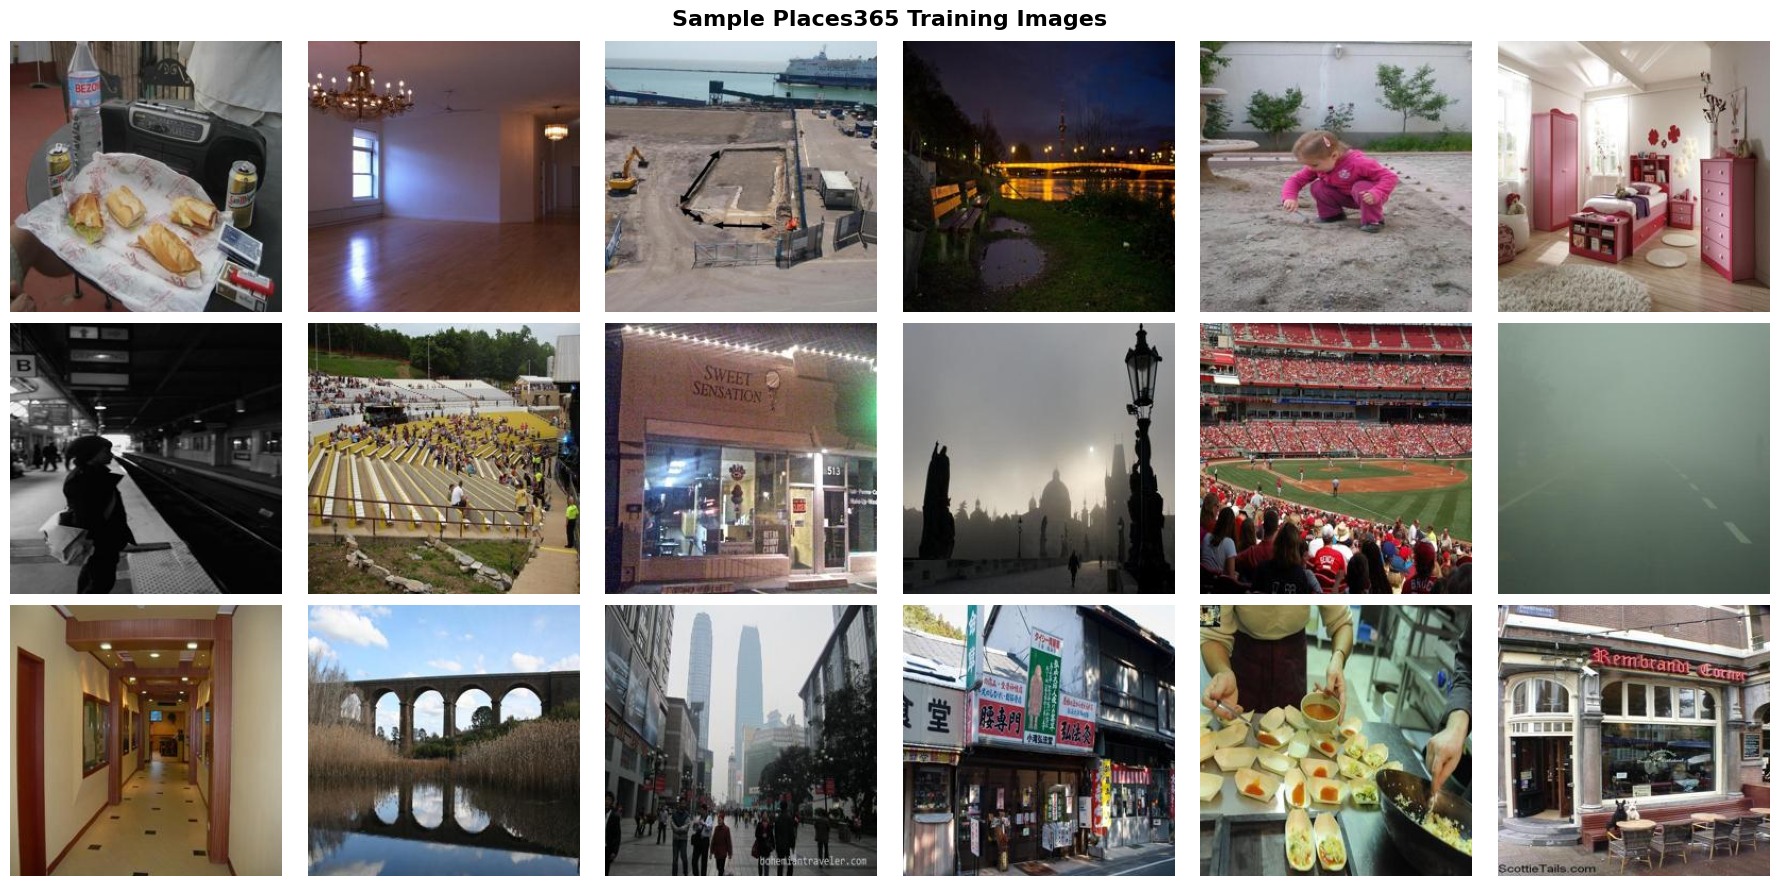

Saved: results/eda_sample_grid.png


In [11]:
# ── 4.2 Sample Grid of Places365 Images ──────────────────────
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle("Sample Places365 Training Images", fontsize=16, fontweight="bold")

rng = np.random.RandomState(42)
sample_idxs = rng.choice(len(train_paths), 18, replace=False)

for i, ax in enumerate(axes.flat):
    img = Image.open(train_paths[sample_idxs[i]]).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(np.array(img))
    ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/eda_sample_grid.png")

### 4.3 Resolution Distribution
Scans 1 000 images to plot width, height, and aspect-ratio histograms. Confirms that the dataset is broadly square and justifies resizing everything to 256×256.

Scanning resolutions:   0%|          | 0/1000 [00:00<?, ?it/s]

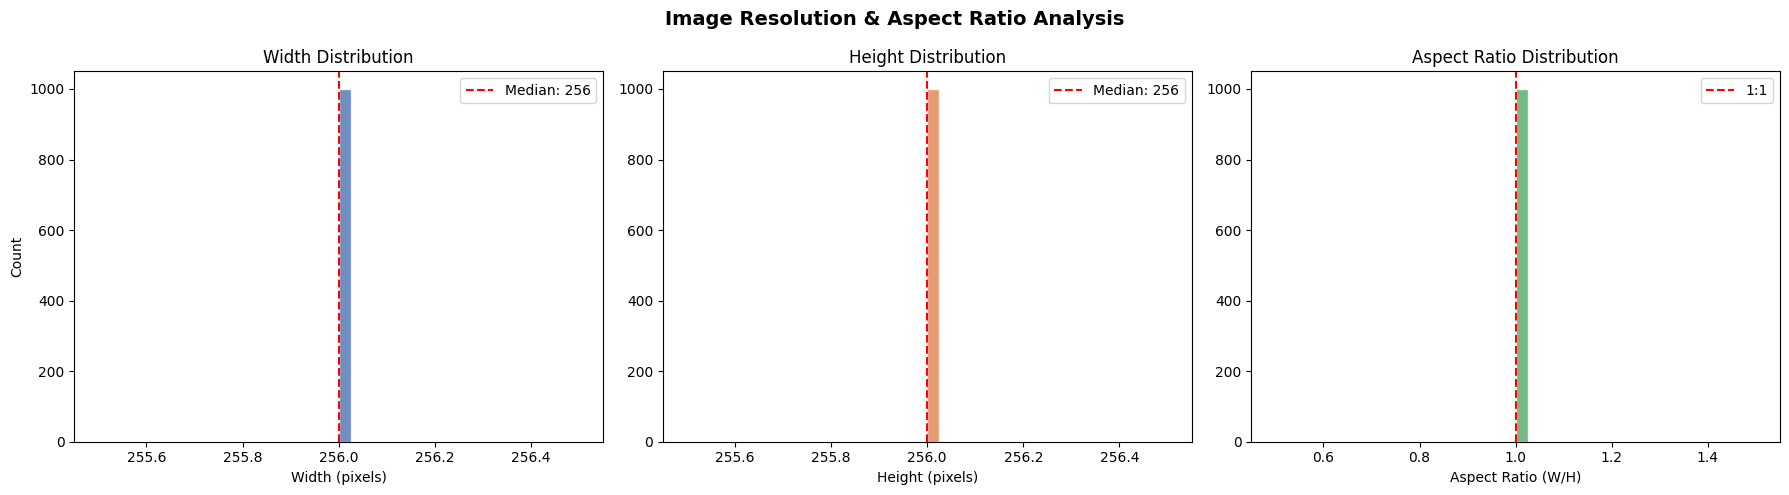

Resolution stats — W: 256 ± 0, H: 256 ± 0


In [12]:
# ── 4.3 Image Resolution Distribution ────────────────────────
n_sample = min(1000, len(train_paths))
rng = np.random.RandomState(42)
scan_paths = rng.choice(train_paths, n_sample, replace=False)

widths, heights, aspects = [], [], []
for p in tqdm(scan_paths, desc="Scanning resolutions"):
    img = Image.open(p)
    w, h = img.size
    widths.append(w)
    heights.append(h)
    aspects.append(w / h)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Image Resolution & Aspect Ratio Analysis", fontsize=14, fontweight="bold")

axes[0].hist(widths, bins=40, color="#4C72B0", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Count")
axes[0].set_title("Width Distribution")
axes[0].axvline(np.median(widths), color="red", ls="--",
                label=f"Median: {np.median(widths):.0f}")
axes[0].legend()

axes[1].hist(heights, bins=40, color="#DD8452", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Height (pixels)")
axes[1].set_title("Height Distribution")
axes[1].axvline(np.median(heights), color="red", ls="--",
                label=f"Median: {np.median(heights):.0f}")
axes[1].legend()

axes[2].hist(aspects, bins=40, color="#55A868", edgecolor="white", alpha=0.8)
axes[2].set_xlabel("Aspect Ratio (W/H)")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].axvline(1.0, color="red", ls="--", label="1:1")
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_resolution_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Resolution stats — W: {np.mean(widths):.0f} ± {np.std(widths):.0f}, "
      f"H: {np.mean(heights):.0f} ± {np.std(heights):.0f}")

### 4.4 RGB Intensity Distribution
Per-channel pixel histograms sampled from 200 training images. Validates that no channel is systematically clipped and that the data is suitable for training without per-channel normalisation.

Pixel stats:   0%|          | 0/200 [00:00<?, ?it/s]

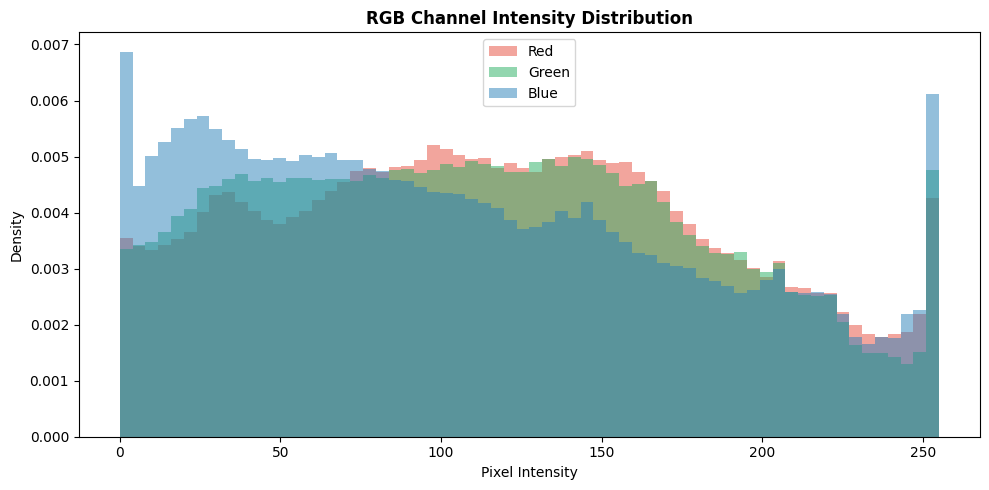

In [13]:
# ── 4.4 Pixel Intensity Distribution (RGB channels) ──────────
n_pix_sample = min(200, len(train_paths))
rng = np.random.RandomState(42)
pix_paths = rng.choice(train_paths, n_pix_sample, replace=False)

channel_vals: Dict[str, list] = {"Red": [], "Green": [], "Blue": []}
for p in tqdm(pix_paths, desc="Pixel stats"):
    arr = np.array(Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    # Subsample every 16th pixel to keep memory manageable
    channel_vals["Red"].extend(arr[:, :, 0].ravel()[::16].tolist())
    channel_vals["Green"].extend(arr[:, :, 1].ravel()[::16].tolist())
    channel_vals["Blue"].extend(arr[:, :, 2].ravel()[::16].tolist())

fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {"Red": "#e74c3c", "Green": "#27ae60", "Blue": "#2980b9"}
for ch_name, vals in channel_vals.items():
    ax.hist(vals, bins=64, alpha=0.5, color=colors_map[ch_name],
            label=ch_name, density=True)
ax.set_xlabel("Pixel Intensity")
ax.set_ylabel("Density")
ax.set_title("RGB Channel Intensity Distribution", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_pixel_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.5 Mask Coverage Distribution
Samples 500 random free-form masks and histograms their coverage percentages. The four difficulty bins (easy / mid / hard / x-hard) are overlaid to show the training distribution.

Sampling 500 random masks for coverage analysis ...


Mask coverage:   0%|          | 0/500 [00:00<?, ?it/s]

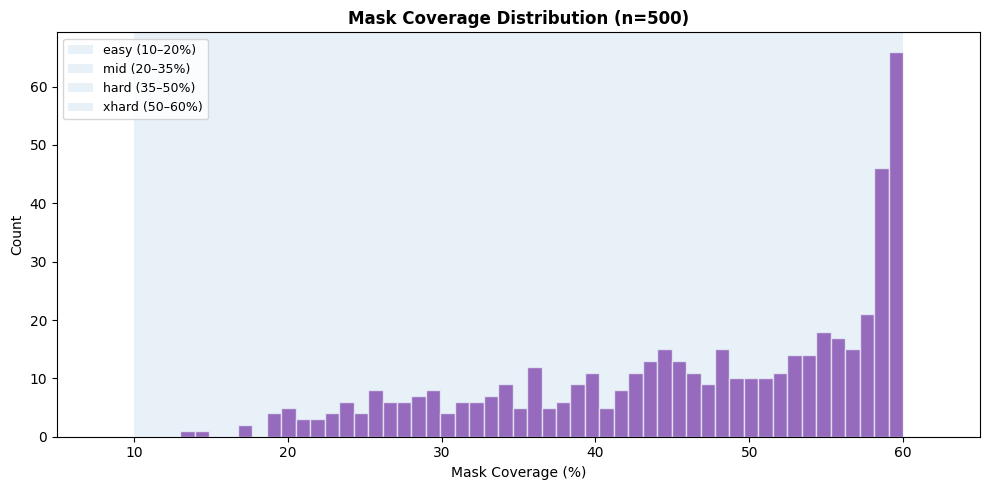

Coverage stats — mean: 46.4%, std: 12.0%


In [14]:
# ── 4.5 Mask Coverage Distribution ───────────────────────────
n_mask_sample = 500
print(f"Sampling {n_mask_sample} random masks for coverage analysis ...")

saved_state = np.random.get_state()
np.random.seed(SEED)
coverages = [
    generate_freeform_mask(IMG_SIZE, IMG_SIZE).mean() * 100
    for _ in tqdm(range(n_mask_sample), desc="Mask coverage")
]
np.random.set_state(saved_state)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(coverages, bins=50, color="#8E44AD", edgecolor="white", alpha=0.8)
ax.set_xlabel("Mask Coverage (%)")
ax.set_ylabel("Count")
ax.set_title(f"Mask Coverage Distribution (n={n_mask_sample})", fontweight="bold")

for name, (lo, hi) in MASK_BINS.items():
    ax.axvspan(lo*100, hi*100, alpha=0.1, label=f"{name} ({lo*100:.0f}–{hi*100:.0f}%)")
ax.legend(fontsize=9)
ax.set_xlim(5, 65)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_mask_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Coverage stats — mean: {np.mean(coverages):.1f}%, std: {np.std(coverages):.1f}%")

### 4.6 Example Masks by Difficulty
Visualises one representative mask and corresponding masked input image for each difficulty bin, giving intuition for what the model must reconstruct.

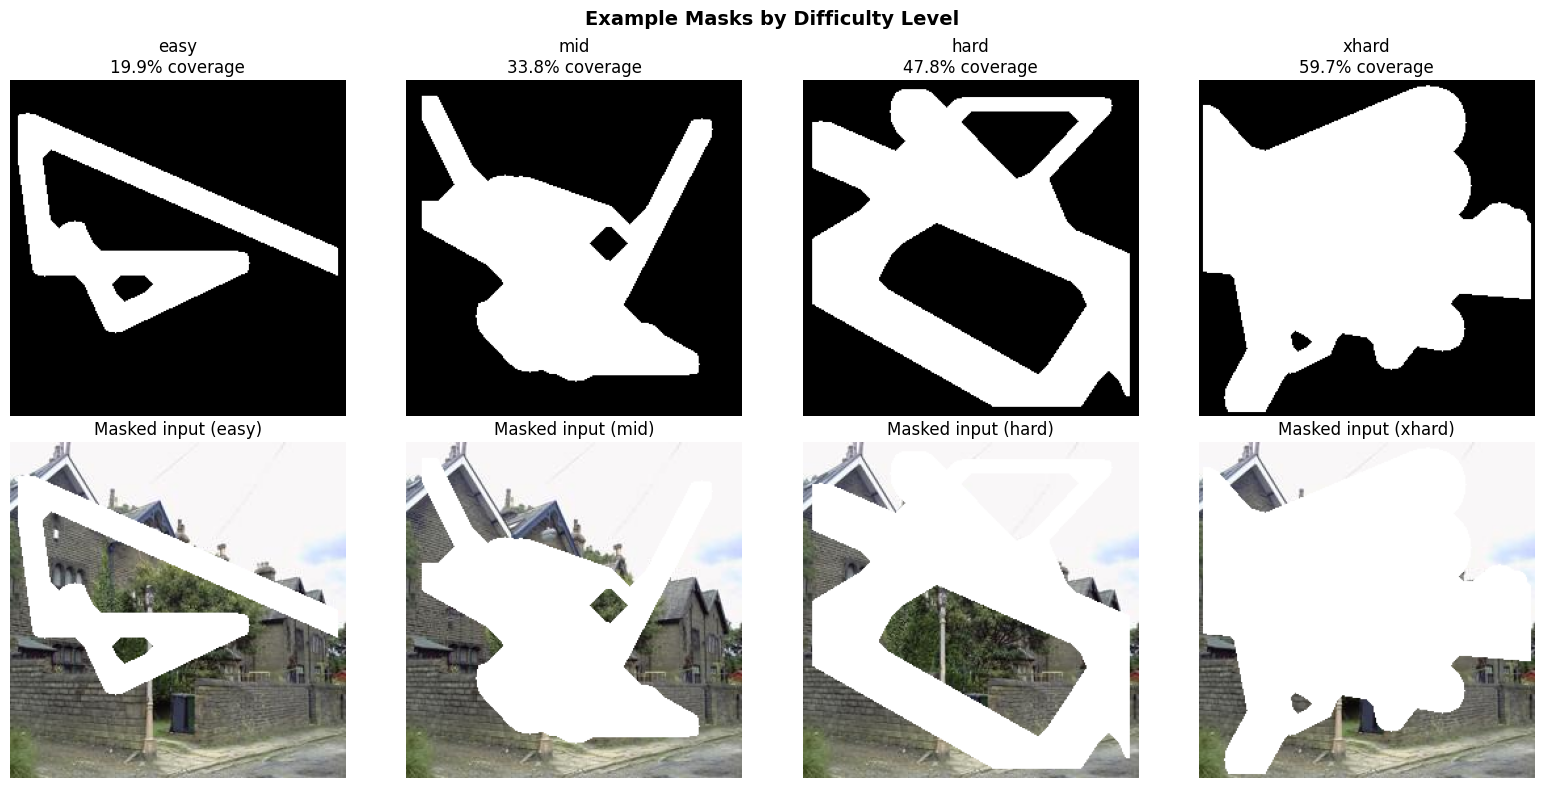

In [15]:
# ── 4.6 Example Masks at Different Coverage Levels ───────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Example Masks by Difficulty Level", fontsize=14, fontweight="bold")

sample_img = np.array(
    Image.open(train_paths[0]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
)

saved_state = np.random.get_state()
np.random.seed(SEED + 100)

for col, (bin_name, (lo, hi)) in enumerate(MASK_BINS.items()):
    # Generate a mask that genuinely falls within the bin.
    # generate_freeform_mask now enforces bounds, so this should
    # succeed on the first or second try.
    mask, cov = None, -1.0
    for attempt in range(200):
        m = generate_freeform_mask(IMG_SIZE, IMG_SIZE, (lo, hi))
        c = m.mean()
        if lo <= c <= hi:
            mask, cov = m, c
            break
    if mask is None:
        print(f"  Warning: could not satisfy bin '{bin_name}' after 200 attempts. "
              f"Using best approximation (cov={c:.3f}).")
        mask, cov = m, c

    axes[0, col].imshow(mask, cmap="gray")
    axes[0, col].set_title(f"{bin_name}\n{cov*100:.1f}% coverage")
    axes[0, col].axis("off")

    masked_img = sample_img.copy()
    masked_img[mask > 0.5] = 255
    axes[1, col].imshow(masked_img)
    axes[1, col].set_title(f"Masked input ({bin_name})")
    axes[1, col].axis("off")

np.random.set_state(saved_state)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_mask_examples.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.7 Boundary Band Visualisation
Illustrates the bilateral boundary band used by all boundary-aware loss terms: a dilation of `BOUNDARY_DILATION` pixels on each side of the mask edge.

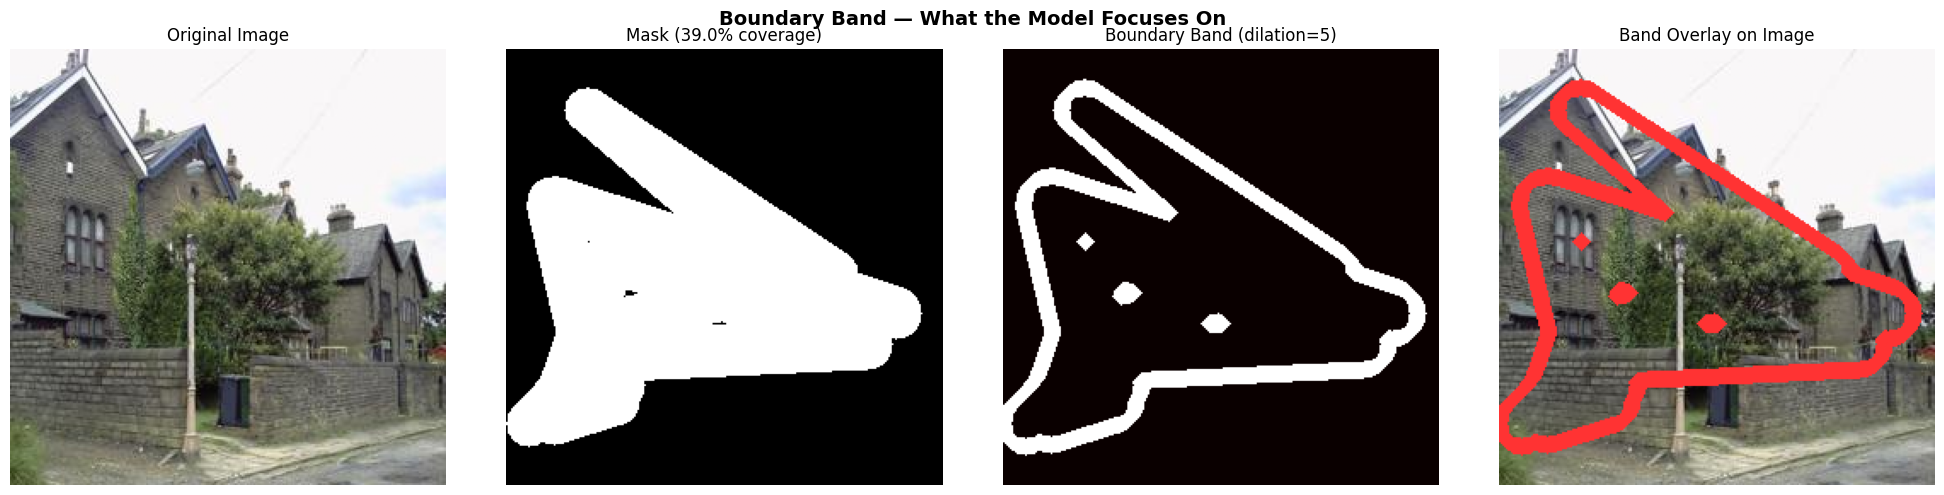

In [16]:
# ── 4.7 Boundary Band Visualisation ──────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Boundary Band — What the Model Focuses On", fontsize=14, fontweight="bold")

saved_state = np.random.get_state()
np.random.seed(SEED + 200)
mask = generate_freeform_mask(IMG_SIZE, IMG_SIZE, (0.25, 0.40))
np.random.set_state(saved_state)

band             = get_boundary_band(mask)
sample_img_norm  = sample_img.astype(np.float32) / 255.0

axes[0].imshow(sample_img_norm)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"Mask ({mask.mean()*100:.1f}% coverage)")
axes[1].axis("off")

axes[2].imshow(band, cmap="hot")
axes[2].set_title(f"Boundary Band (dilation={BOUNDARY_DILATION})")
axes[2].axis("off")

overlay = sample_img_norm.copy()
overlay[band > 0.5] = [1.0, 0.2, 0.2]   # red highlight
axes[3].imshow(overlay)
axes[3].set_title("Band Overlay on Image")
axes[3].axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_boundary_band.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.8 Stage 1 Baseline Reference
> The numbers below are **reference baselines from prior published work**, not results from this notebook. They motivate the need for boundary-aware supervision and set indicative improvement targets.

Stage 1 Baseline Metrics (reference — needs verification)
  PSNR: 19.46
  SSIM: 0.6845
  Hole-MAE: 0.3227
NOTE: These are prior-work baselines. Actual results will
appear in §13 after training completes.


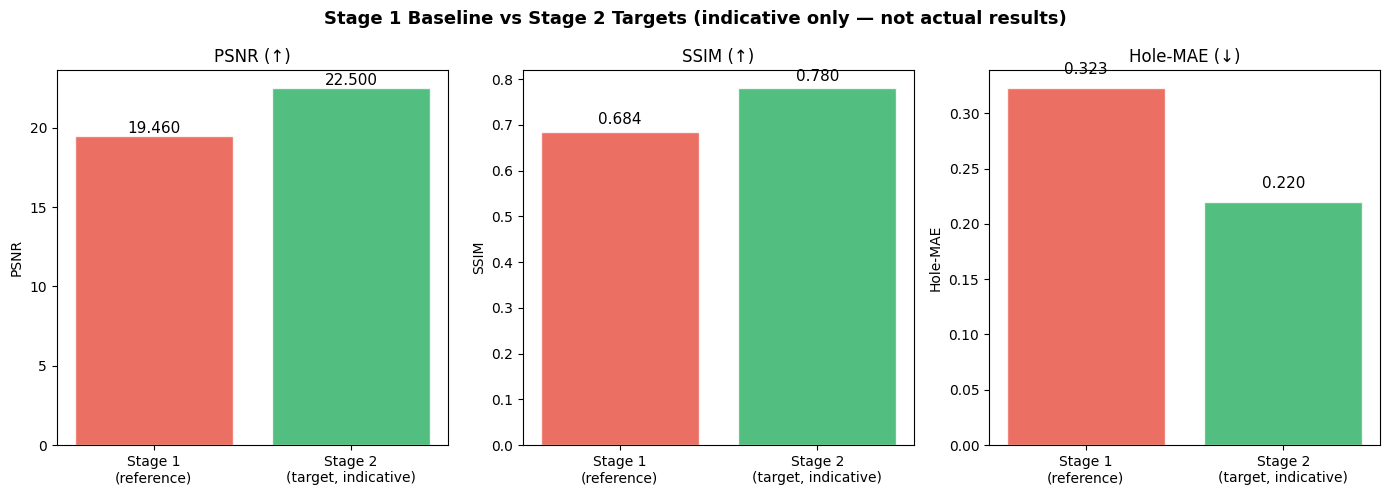

In [ ]:
# ── 4.8 Stage 1 Baseline Reminder ────────────────────────────
#
# IMPORTANT: The values below are REFERENCE BASELINES from
# prior published work, NOT results produced by this notebook.
# They motivate why boundary-aware spectral supervision is needed.
# The "Stage 2 targets" are indicative research goals only and
# will be replaced by actual results once training completes.
#
print("=" * 60)
print("Stage 1 Baseline Metrics (reference — needs verification)")
print("=" * 60)
stage1_metrics = {"PSNR": 19.46, "SSIM": 0.6845, "Hole-MAE": 0.3227}
for k, v in stage1_metrics.items():
    print(f"  {k}: {v}")
print("=" * 60)
print("NOTE: These are prior-work baselines. Actual results will")
print("appear in §13 after training completes.")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    "Stage 1 Baseline vs Stage 2 Targets (indicative only — not actual results)",
    fontsize=13, fontweight="bold",
)

metrics       = ["PSNR (↑)", "SSIM (↑)", "Hole-MAE (↓)"]
stage1_vals   = [19.46, 0.6845, 0.3227]
expected_vals = [22.5,  0.78,   0.22]   # indicative targets, NOT measured results

for i, (name, s1, s2) in enumerate(zip(metrics, stage1_vals, expected_vals)):
    bars = axes[i].bar(
        ["Stage 1\n(reference)", "Stage 2\n(target, indicative)"],
        [s1, s2], color=["#e74c3c", "#27ae60"], alpha=0.8, edgecolor="white",
    )
    axes[i].set_title(name)
    axes[i].set_ylabel(name.split(" ")[0])
    for bar in bars:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=11,
        )

plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_stage1_vs_stage2.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Model Architecture

We implement a ResNet-based encoder-decoder with:
- **4-channel input** (RGB + mask) for the encoder
- **Mask-injected gated skip connections** between encoder and decoder
- **Gated convolution** decoder blocks
- **Multi-scale output heads** for boundary supervision

In [18]:
# ── 5.1 Gated Convolution Block ───────────────────────────────
class GatedConv2d(nn.Module):
    """Gated convolution: out = sigmoid(gate) ⊙ activation(feature).

    Reference: Yu et al., "Free-Form Image Inpainting with Gated Convolution", ICCV 2019.
    """

    def __init__(
        self,
        in_ch: int,
        out_ch: int,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
        activation: Optional[nn.Module] = None,
    ):
        super().__init__()
        self.feature_conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding)
        self.gate_conv    = nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding)
        # Default activation is ELU; caller may override per layer
        self.activation   = activation if activation is not None else nn.ELU(inplace=True)
        self.bn           = nn.BatchNorm2d(out_ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feature = self.activation(self.bn(self.feature_conv(x)))
        gate    = torch.sigmoid(self.gate_conv(x))
        return feature * gate


class StandardConv2d(nn.Module):
    """Standard conv → BN → ELU block, used as the ablation baseline."""

    def __init__(
        self,
        in_ch: int,
        out_ch: int,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
        activation: Optional[nn.Module] = None,
    ):
        super().__init__()
        act = activation if activation is not None else nn.ELU(inplace=True)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            act,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


print("Gated / standard convolution blocks defined.")

Gated / standard convolution blocks defined.


### 5.2 Skip Connection Modules
Two variants are defined for the ablation study: `MaskInjectedSkipGate` computes a soft attention map from encoder features, decoder features, and the downsampled mask; `StandardSkipConnection` is an identity passthrough baseline.

In [19]:
# ── 5.2 Skip Connection Modules ───────────────────────────────
class MaskInjectedSkipGate(nn.Module):
    """Attention-gated skip connection that incorporates mask information.

    Combines encoder features, decoder features, and the downsampled
    mask to produce a soft attention map that weights the encoder skip.
    """

    def __init__(self, enc_ch: int, dec_ch: int):
        super().__init__()
        self.W_enc  = nn.Conv2d(enc_ch, dec_ch, 1, bias=False)
        self.W_dec  = nn.Conv2d(dec_ch, dec_ch, 1, bias=False)
        self.W_mask = nn.Conv2d(1,      dec_ch, 1, bias=False)
        self.psi    = nn.Sequential(
            nn.Conv2d(dec_ch, 1, 1, bias=False),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(
        self,
        enc_feat: torch.Tensor,   # (B, enc_ch, H, W)
        dec_feat: torch.Tensor,   # (B, dec_ch, H, W)
        mask: torch.Tensor,        # (B, 1, H_orig, W_orig)
    ) -> torch.Tensor:
        mask_ds = F.interpolate(mask, size=enc_feat.shape[2:], mode="nearest")
        g       = self.relu(
            self.W_enc(enc_feat) + self.W_dec(dec_feat) + self.W_mask(mask_ds)
        )
        alpha = self.psi(g)   # (B, 1, H, W)
        return enc_feat * alpha


class StandardSkipConnection(nn.Module):
    """Identity skip connection — returns encoder features unchanged (ablation)."""

    def __init__(self, enc_ch: int, dec_ch: int):   # noqa: signature parity
        super().__init__()   # FIX: missing super().__init__() in original

    def forward(
        self,
        enc_feat: torch.Tensor,
        dec_feat: torch.Tensor,
        mask: torch.Tensor,
    ) -> torch.Tensor:
        return enc_feat


print("Skip connection modules defined.")

Skip connection modules defined.


### 5.3 Full Model — BoundaryAwareInpainter
The complete encoder-decoder. A pretrained ResNet backbone encodes the 4-channel input (RGB + mask); the decoder upsamples through skip connections using whichever conv and skip-gate variants were selected in Phases 1–3.

In [20]:

# ── 5.3 Full Inpainting Model ─────────────────────────────────
class BoundaryAwareInpainter(nn.Module):
    """ResNet encoder + gated decoder with mask-injected skip connections.

    Parameters
    ----------
    backbone          : 'resnet18' | 'resnet34'
    use_attention_skip: use MaskInjectedSkipGate (True) or identity skip (False)
    use_gated_conv    : use GatedConv2d in decoder (True) or StandardConv2d (False)
    multiscale_output : produce /8 and /4 auxiliary outputs for boundary supervision
    """

    def __init__(
        self,
        backbone: str = "resnet34",
        use_attention_skip: bool = True,
        use_gated_conv: bool = True,
        multiscale_output: bool = False,
    ):
        super().__init__()
        self.use_attention_skip = use_attention_skip
        self.use_gated_conv = use_gated_conv
        self.multiscale_output = multiscale_output

        # ── Encoder ───────────────────────────────────────────
        if backbone == "resnet18":
            resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        elif backbone == "resnet34":
            resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        else:
            raise ValueError(
                f"Unsupported backbone: '{backbone}'. "
                "Choose 'resnet18' or 'resnet34'."
            )

        # Expand first conv: 3 → 4 channels (RGB + mask)
        old_conv = resnet.conv1
        self.enc_conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.enc_conv1.weight[:, :3] = old_conv.weight          # copy RGB weights
            self.enc_conv1.weight[:, 3:] = old_conv.weight[:, :1]   # init mask ch from R

        self.enc_bn1 = resnet.bn1
        self.enc_relu = resnet.relu
        self.enc_pool = resnet.maxpool
        self.enc_layer1 = resnet.layer1   # /4,  64 ch
        self.enc_layer2 = resnet.layer2   # /8,  128 ch
        self.enc_layer3 = resnet.layer3   # /16, 256 ch
        self.enc_layer4 = resnet.layer4   # /32, 512 ch

        # ── Skip connections ───────────────────────────────────
        SkipCls = MaskInjectedSkipGate if use_attention_skip else StandardSkipConnection
        self.skip4 = SkipCls(256, 512)  # e3 (256) -> d4 (512)
        self.skip3 = SkipCls(128, 256)  # e2 (128) -> d3 (256)
        self.skip2 = SkipCls(64, 128)   # e1 (64)  -> d2 (128)
        self.skip1 = SkipCls(64, 64)    # e0 (64)  -> d1 (64)

        # ── Decoder ───────────────────────────────────────────
        ConvBlk = GatedConv2d if use_gated_conv else StandardConv2d

        self.dec4_up = nn.ConvTranspose2d(512, 512, 2, stride=2)   # /32 -> /16
        self.dec4_conv = ConvBlk(512 + 256, 256)

        self.dec3_up = nn.ConvTranspose2d(256, 256, 2, stride=2)   # /16 -> /8
        self.dec3_conv = ConvBlk(256 + 128, 128)

        self.dec2_up = nn.ConvTranspose2d(128, 128, 2, stride=2)   # /8 -> /4
        self.dec2_conv = ConvBlk(128 + 64, 64)

        self.dec1_up = nn.ConvTranspose2d(64, 64, 2, stride=2)     # /4 -> /2
        self.dec1_conv = ConvBlk(64 + 64, 64)

        self.final_up = nn.ConvTranspose2d(64, 32, 2, stride=2)    # /2 -> /1
        self.final_conv = nn.Sequential(
            ConvBlk(32, 32),
            nn.Conv2d(32, 3, 1),
            nn.Sigmoid(),
        )

        # ── Multi-scale auxiliary heads ────────────────────────
        if self.multiscale_output:
            self.ms_head_8 = nn.Sequential(
                ConvBlk(128, 64),
                nn.Conv2d(64, 3, 1),
                nn.Sigmoid(),
            )  # at /8 scale
            self.ms_head_4 = nn.Sequential(
                ConvBlk(64, 32),
                nn.Conv2d(32, 3, 1),
                nn.Sigmoid(),
            )  # at /4 scale

    def forward(
        self,
        x: torch.Tensor,                    # (B, 3, H, W)
        mask: Optional[torch.Tensor] = None,   # (B, 1, H, W), 1=hole
    ) -> Dict[str, object]:
        """Forward pass.

        Returns a dict with:
            'output'     : (B, 3, H, W) inpainted image in [0, 1]
            'ms_outputs' : list of auxiliary outputs (may be empty)
        """
        if mask is None:
            mask = torch.zeros(
                x.shape[0], 1, x.shape[2], x.shape[3], device=x.device
            )

        # 4-channel encoder input: RGB + mask
        enc_in = torch.cat([x, mask], dim=1)

        # ── Encoder ───────────────────────────────────────────
        e0 = self.enc_relu(self.enc_bn1(self.enc_conv1(enc_in)))   # /2,  64 ch
        e0p = self.enc_pool(e0)                                    # /4,  64 ch
        e1 = self.enc_layer1(e0p)                                  # /4,  64 ch
        e2 = self.enc_layer2(e1)                                   # /8,  128 ch
        e3 = self.enc_layer3(e2)                                   # /16, 256 ch
        e4 = self.enc_layer4(e3)                                   # /32, 512 ch

        # ── Decoder with skip connections ─────────────────────
        d4 = self.dec4_up(e4)                                      # /16, 512 ch
        s4 = self.skip4(e3, d4, mask)                              # 256 ch
        d4 = self.dec4_conv(torch.cat([d4, s4], dim=1))            # 256 ch

        d3 = self.dec3_up(d4)                                      # /8, 256 ch
        s3 = self.skip3(e2, d3, mask)                              # 128 ch
        d3 = self.dec3_conv(torch.cat([d3, s3], dim=1))            # 128 ch

        d2 = self.dec2_up(d3)                                      # /4, 128 ch
        s2 = self.skip2(e1, d2, mask)                              # 64 ch
        d2 = self.dec2_conv(torch.cat([d2, s2], dim=1))            # 64 ch

        d1 = self.dec1_up(d2)                                      # /2, 64 ch
        s1 = self.skip1(e0, d1, mask)                              # 64 ch
        d1 = self.dec1_conv(torch.cat([d1, s1], dim=1))            # 64 ch

        out = self.final_up(d1)                                    # /1
        out = self.final_conv(out)                                 # (B, 3, H, W)

        result = {"output": out, "ms_outputs": []}

        if self.multiscale_output:
            result["ms_outputs"] = [
                self.ms_head_8(d3),   # /8
                self.ms_head_4(d2),   # /4
            ]

        return result


# ── Smoke test ────────────────────────────────────────────────
_m = BoundaryAwareInpainter("resnet34", True, True, True).to(DEVICE)
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
_mk = torch.randint(0, 2, (2, 1, IMG_SIZE, IMG_SIZE), device=DEVICE).float()

with torch.no_grad():
    _out = _m(_x, _mk)

assert _out["output"].shape == (2, 3, IMG_SIZE, IMG_SIZE), "Output shape mismatch!"
assert len(_out["ms_outputs"]) == 2, "Expected 2 multi-scale outputs!"

n_params = sum(p.numel() for p in _m.parameters()) / 1e6
print(f"Model output shape:   {_out['output'].shape}")
print(f"MS output shapes:     {[o.shape for o in _out['ms_outputs']]}")
print(f"Total parameters:     {n_params:.2f} M")

del _m, _x, _mk, _out
torch.cuda.empty_cache()



Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 213MB/s]


Model output shape:   torch.Size([2, 3, 256, 256])
MS output shapes:     [torch.Size([2, 3, 32, 32]), torch.Size([2, 3, 64, 64])]
Total parameters:     28.21 M


## 6. Loss Functions

In [21]:
# ── 6.1 Perceptual Loss (VGG16, conv1_2 through conv3_2) ─────
class PerceptualLoss(nn.Module):
    """VGG16 perceptual loss up to relu3_2 (first 16 layers).

    Gradients flow through the *prediction* branch only; the target
    features are computed inside torch.no_grad().
    The VGG backbone is frozen and never updated.
    """

    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features[:16]
        self.feature_extractor = vgg.eval()
        for p in self.feature_extractor.parameters():
            p.requires_grad = False

        # ImageNet normalisation constants (match VGG preprocessing)
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        pred_n   = (pred   - self.mean) / self.std
        target_n = (target - self.mean) / self.std
        feat_pred = self.feature_extractor(pred_n)
        with torch.no_grad():
            feat_target = self.feature_extractor(target_n)
        return F.l1_loss(feat_pred, feat_target)


print("PerceptualLoss defined (VGG16 relu3_2, frozen, grad through pred only).")

PerceptualLoss defined (VGG16 relu3_2, frozen, grad through pred only).


### 6.2 Boundary Losses
Two boundary-localised reconstruction terms: **uniform** L1 (equal weight across the band) and **gradient-weighted** L1 (higher penalty near edges detected by Sobel filters). Compared in the Phase 4 ablation.

In [22]:
# ── 6.2 Boundary Losses ───────────────────────────────────────

def sobel_gradient_magnitude(img: torch.Tensor) -> torch.Tensor:
    """Per-channel Sobel gradient magnitude, reduced to a single-channel max.

    Parameters
    ----------
    img : (B, C, H, W) float tensor

    Returns
    -------
    grad_mag : (B, 1, H, W) float tensor
    """
    sobel_x = torch.tensor(
        [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
        dtype=img.dtype, device=img.device,
    ).view(1, 1, 3, 3)
    sobel_y = torch.tensor(
        [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
        dtype=img.dtype, device=img.device,
    ).view(1, 1, 3, 3)

    B, C, H, W = img.shape
    grad_mag = torch.zeros(B, 1, H, W, device=img.device, dtype=img.dtype)
    for c in range(C):
        ch = img[:, c:c+1]
        gx = F.conv2d(ch, sobel_x, padding=1)
        gy = F.conv2d(ch, sobel_y, padding=1)
        # epsilon inside sqrt prevents zero-gradient at flat regions
        grad_mag = torch.max(grad_mag, torch.sqrt(gx**2 + gy**2 + 1e-8))
    return grad_mag


class GradientWeightedBoundaryLoss(nn.Module):
    """Boundary L1 loss, weighted by the Sobel gradient magnitude of the target.

    Pixels with strong edges in the target receive higher loss weight,
    concentrating supervision on high-frequency boundary content.
    """

    def __init__(self):
        super().__init__()

    def forward(
        self,
        pred: torch.Tensor,
        target: torch.Tensor,
        boundary_band: torch.Tensor,
    ) -> torch.Tensor:
        """
        pred, target   : (B, 3, H, W)
        boundary_band  : (B, 1, H, W)
        """
        with torch.no_grad():
            grad_w = sobel_gradient_magnitude(target)        # (B, 1, H, W)
            grad_w = grad_w / (grad_w.max() + 1e-8)         # normalise to [0, 1]
            grad_w = grad_w * boundary_band                  # restrict to band

        diff         = torch.abs(pred - target)              # (B, 3, H, W)
        weighted     = diff * grad_w                         # broadcasts over C
        n_band_pixels = boundary_band.sum().clamp(min=1.0)
        # Divide by band area × channels to get a per-pixel, per-channel mean
        return weighted.sum() / (n_band_pixels * 3)


class UniformBoundaryLoss(nn.Module):
    """Uniform (unweighted) boundary L1 loss — ablation baseline (L1)."""

    def __init__(self):
        super().__init__()

    def forward(
        self,
        pred: torch.Tensor,
        target: torch.Tensor,
        boundary_band: torch.Tensor,
    ) -> torch.Tensor:
        diff    = torch.abs(pred - target) * boundary_band
        n_band  = boundary_band.sum().clamp(min=1.0)
        return diff.sum() / (n_band * 3)


print("Boundary loss modules defined.")

Boundary loss modules defined.


### 6.3 Spectral Boundary Coherence Loss 
The novel contribution of this work. Patches are sampled along the boundary band and their FFT magnitude spectra are compared between the composite and the ground truth, penalising frequency-domain discontinuities that pixel-space losses miss.

In [23]:
# ── 6.3 Spectral Boundary Coherence Loss ─────────────────────
class SpectralBoundaryCoherenceLoss(nn.Module):
    """FFT magnitude mismatch between composite and target on boundary patches.

    Up to `n_samples` patch pairs are sampled per image from the boundary
    band, their FFT magnitudes are compared with L1, and the result is
    averaged.  Returns a zero tensor (with no gradient) when no valid
    boundary pixels exist in the batch.
    """

    def __init__(self, patch_size: int = 16, n_samples: int = 8):
        super().__init__()
        self.patch_size = patch_size
        self.n_samples  = n_samples

    def forward(
        self,
        pred: torch.Tensor,
        target: torch.Tensor,
        mask: torch.Tensor,
        boundary_band: torch.Tensor,
    ) -> torch.Tensor:
        B, C, H, W = pred.shape
        ps = self.patch_size

        # Composite: target in known regions, pred in hole
        comp = target * (1 - mask) + pred * mask

        band_flat   = boundary_band.view(B, -1)   # (B, H*W)
        patch_losses: List[torch.Tensor] = []

        for b in range(B):
            nz = torch.nonzero(band_flat[b] > 0.5, as_tuple=False)   # (N, 1)
            if len(nz) < 4:
                continue
            n_draw  = min(self.n_samples, len(nz))
            indices = nz[torch.randperm(len(nz), device=pred.device)[:n_draw], 0]

            for idx in indices:
                y, x = int(idx) // W, int(idx) % W
                y0 = max(0, y - ps // 2)
                x0 = max(0, x - ps // 2)
                y1 = min(H, y0 + ps)
                x1 = min(W, x0 + ps)
                # Skip patches that are too small (near image border)
                if (y1 - y0) < ps // 2 or (x1 - x0) < ps // 2:
                    continue

                p_comp   = comp[b,   :, y0:y1, x0:x1]
                p_target = target[b, :, y0:y1, x0:x1]

                mag_comp   = torch.abs(torch.fft.fft2(p_comp))
                mag_target = torch.abs(torch.fft.fft2(p_target))

                patch_losses.append(F.l1_loss(mag_comp, mag_target.detach()))

        if patch_losses:
            return torch.stack(patch_losses).mean()
        # No boundary pixels in this batch — return a grad-connected zero
        return pred.sum() * 0.0


print("SpectralBoundaryCoherenceLoss defined.")

SpectralBoundaryCoherenceLoss defined.


### 6.4 Total Variation Loss
Smooths the inpainted region by penalising pixel-level variation *inside the hole only*, avoiding over-smoothing of known valid pixels.

In [24]:
# ── 6.4 Total Variation Loss ──────────────────────────────────
class TVLoss(nn.Module):
    """Total Variation loss restricted to the hole region.

    Promotes spatial smoothness inside the inpainted area without
    penalising sharp edges in the known (valid) region.
    """

    def __init__(self):
        super().__init__()

    def forward(self, pred: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
        pred : (B, 3, H, W)
        mask : (B, 1, H, W), 1 = hole
        """
        pred_hole = pred * mask
        diff_h = torch.abs(pred_hole[:, :, 1:, :]  - pred_hole[:, :, :-1, :])
        diff_w = torch.abs(pred_hole[:, :, :, 1:]  - pred_hole[:, :, :, :-1])
        return diff_h.mean() + diff_w.mean()


print("TVLoss defined.")

TVLoss defined.


### 6.5 Combined Loss Manager
Orchestrates all loss components via a `loss_config` string. Configs used in Phase 4: `base`, `boundary_uniform`, `boundary_grad`, `spectral_only`, and `full` (all terms active).

In [25]:
# ── 6.5 Combined Loss Manager ─────────────────────────────────
class InpaintingLossManager:
    """Manages all loss components for the inpainting model.

    loss_config controls which losses are active:

        'base'             : hole + valid + perceptual
        'boundary_uniform' : base + uniform boundary L1
        'boundary_grad'    : base + gradient-weighted boundary L1
        'spectral_only'    : base + spectral coherence loss
        'full'             : all losses + multi-scale boundary supervision
    """

    def __init__(self, loss_config: str, device: torch.device):
        self.config = loss_config
        self.device = device

        self.perceptual_loss  = PerceptualLoss().to(device)
        self.uniform_boundary = UniformBoundaryLoss()
        self.grad_boundary    = GradientWeightedBoundaryLoss()
        self.spectral_loss    = SpectralBoundaryCoherenceLoss().to(device)
        self.tv_loss          = TVLoss()

    def compute(
        self,
        pred_dict: Dict[str, object],
        target: torch.Tensor,
        mask: torch.Tensor,
        boundary_band: torch.Tensor,
    ) -> Dict[str, torch.Tensor]:
        """Compute the total loss and a per-component breakdown."""
        pred       = pred_dict["output"]
        hole_mask  = mask          # 1 = hole
        valid_mask = 1.0 - mask    # 1 = valid
        losses: Dict[str, torch.Tensor] = {}

        # ── Base losses (always active) ───────────────────────
        # Pixel-wise L1 normalised by region coverage:
        #   sum(|pred - target| * region) / sum(region) / 3
        # This avoids the approximation in the original code that divided
        # the batch-mean L1 by mask.mean() (slightly biased for small masks).
        n_hole  = hole_mask.sum().clamp(min=1.0)
        n_valid = valid_mask.sum().clamp(min=1.0)
        losses["hole_l1"]  = (torch.abs(pred - target) * hole_mask).sum()  / (n_hole  * 3)
        losses["valid_l1"] = (torch.abs(pred - target) * valid_mask).sum() / (n_valid * 3)
        losses["perceptual"] = self.perceptual_loss(pred, target)

        total = (
            HOLE_LOSS_WEIGHT       * losses["hole_l1"]
            + VALID_LOSS_WEIGHT    * losses["valid_l1"]
            + PERCEPTUAL_LOSS_WEIGHT * losses["perceptual"]
        )

        # ── Uniform boundary loss ─────────────────────────────
        if self.config == "boundary_uniform":
            bl = self.uniform_boundary(pred, target, boundary_band)
            losses["boundary"] = bl
            total = total + BOUNDARY_LOSS_WEIGHT * bl

        # ── Gradient-weighted boundary loss ───────────────────
        if self.config in ("boundary_grad", "full"):
            bl = self.grad_boundary(pred, target, boundary_band)
            losses["boundary"] = bl
            total = total + BOUNDARY_LOSS_WEIGHT * bl

        # ── Spectral coherence loss ───────────────────────────
        if self.config in ("spectral_only", "full"):
            sl = self.spectral_loss(pred, target, mask, boundary_band)
            losses["spectral"] = sl
            total = total + SPECTRAL_LOSS_WEIGHT * sl

        # ── TV loss ───────────────────────────────────────────
        if self.config == "full":
            tv = self.tv_loss(pred, mask)
            losses["tv"] = tv
            total = total + TV_LOSS_WEIGHT * tv

        # ── Multi-scale boundary supervision ──────────────────
        ms_outputs = pred_dict.get("ms_outputs", [])
        if self.config == "full" and len(ms_outputs) > 0:
            ms_total = torch.tensor(0.0, device=self.device)
            for ms_out in ms_outputs:
                scale     = ms_out.shape[2:]
                target_ds = F.interpolate(target, size=scale,
                                          mode="bilinear", align_corners=False)
                band_ds   = F.interpolate(boundary_band, size=scale, mode="nearest")
                ms_total  = ms_total + self.grad_boundary(ms_out, target_ds, band_ds)
            losses["ms_boundary"] = ms_total
            total = total + BOUNDARY_LOSS_WEIGHT * 0.5 * ms_total

        losses["total"] = total
        return losses


print("InpaintingLossManager defined.")

InpaintingLossManager defined.


## 7. Training Infrastructure

In [26]:
# ── 7.1 Cosine Annealing with Linear Warmup ──────────────────
class CosineWarmupScheduler:
    """Per-epoch LR schedule: linear warmup then cosine annealing."""

    def __init__(
        self,
        optimizer: torch.optim.Optimizer,
        warmup_epochs: int,
        total_epochs: int,
        lr_peak: float = LR_PEAK,
        lr_min: float  = LR_MIN,
    ):
        self.optimizer     = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.lr_peak       = lr_peak
        self.lr_min        = lr_min

    def step(self, epoch: int) -> float:
        """Compute and apply the LR for the given epoch (0-indexed)."""
        if epoch < self.warmup_epochs:
            lr = self.lr_peak * (epoch + 1) / max(1, self.warmup_epochs)
        else:
            decay_epochs = max(1, self.total_epochs - self.warmup_epochs)
            progress = (epoch - self.warmup_epochs) / decay_epochs
            lr = self.lr_min + 0.5 * (self.lr_peak - self.lr_min) * (
                1 + math.cos(math.pi * progress)
            )
        for pg in self.optimizer.param_groups:
            pg["lr"] = lr
        return lr


# ── 7.2 Early Stopping ────────────────────────────────────────
class EarlyStopping:
    """Stop training when validation loss has not improved for `patience` epochs."""

    def __init__(self, patience: int = PATIENCE, min_delta: float = 1e-5):
        self.patience    = patience
        self.min_delta   = min_delta
        self.counter     = 0
        self.best_loss   = float("inf")
        self.should_stop = False

    def step(self, val_loss: float) -> bool:
        """Update state and return True if training should stop."""
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


# ── 7.3 Version-safe GradScaler factory ──────────────────────
def make_scaler() -> GradScaler:
    """Create a GradScaler compatible with the installed PyTorch version.

    - On CPU: AMP is disabled (USE_AMP=False), so the scaler is created
      but its scale step is effectively a no-op.
    - On CUDA: uses torch.amp.GradScaler (new API, PyTorch >= 2.3) with a
      fallback to the legacy torch.cuda.amp.GradScaler.

    FIX: the original notebook called GradScaler('cuda') / GradScaler('cpu')
    unconditionally, which raises TypeError on PyTorch < 2.3.
    """
    if not USE_AMP:
        # Return a disabled scaler: no-op on CPU
        if _GRADSCALER_NEW_API:
            return GradScaler("cpu", enabled=False)
        else:
            return GradScaler(enabled=False)
    # CUDA path
    if _GRADSCALER_NEW_API:
        try:
            return GradScaler("cuda")
        except TypeError:
            # GradScaler in this torch version does not accept device arg
            return GradScaler()
    return GradScaler()


print("Scheduler, EarlyStopping, and GradScaler factory defined.")

Scheduler, EarlyStopping, and GradScaler factory defined.


### 7.4 Training & Validation Loops
`train_one_epoch` handles the forward pass, AMP-scaled backward pass, gradient clipping, and metric accumulation. `validate` runs in `torch.no_grad()` and returns average val loss for early stopping.

In [27]:
# ── 7.4 Training and Validation Loops ────────────────────────

def _autocast_ctx():
    """Return an autocast context that is safe on both CUDA and CPU.

    AMP (float16) is enabled only on CUDA.  On CPU we use a null context
    (float32 inference) to avoid unsupported dtype errors.
    """
    if USE_AMP:
        return autocast(device_type="cuda", dtype=torch.float16)
    # On CPU: autocast is a no-op (dtype=float32, enabled=False)
    return autocast(device_type="cpu", dtype=torch.float32, enabled=False)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_manager: InpaintingLossManager,
    optimizer: torch.optim.Optimizer,
    scaler: GradScaler,
    device: torch.device = DEVICE,
    grad_clip: float = GRAD_CLIP,
) -> Dict[str, float]:
    """Run one training epoch and return averaged loss components."""
    model.train()
    running: Dict[str, float] = defaultdict(float)
    n_batches = 0

    for images, masks, boundaries in loader:
        images     = images.to(device,     non_blocking=True)
        masks      = masks.to(device,      non_blocking=True)
        boundaries = boundaries.to(device, non_blocking=True)

        # Mask: 1=hole, 0=valid → zero-fill the hole in the input
        masked_input = images * (1.0 - masks)

        optimizer.zero_grad(set_to_none=True)

        with _autocast_ctx():
            pred_dict = model(masked_input, masks)
            losses    = loss_manager.compute(pred_dict, images, masks, boundaries)

        scaler.scale(losses["total"]).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()

        for k, v in losses.items():
            running[k] += v.item()
        n_batches += 1

    return {k: v / max(n_batches, 1) for k, v in running.items()}


@torch.no_grad()
def validate(
    model: nn.Module,
    loader: DataLoader,
    loss_manager: InpaintingLossManager,
    device: torch.device = DEVICE,
) -> Dict[str, float]:
    """Evaluate on a validation split and return averaged loss components."""
    model.eval()
    running: Dict[str, float] = defaultdict(float)
    n_batches = 0

    for images, masks, boundaries in loader:
        images     = images.to(device,     non_blocking=True)
        masks      = masks.to(device,      non_blocking=True)
        boundaries = boundaries.to(device, non_blocking=True)
        masked_input = images * (1.0 - masks)

        with _autocast_ctx():
            pred_dict = model(masked_input, masks)
            losses    = loss_manager.compute(pred_dict, images, masks, boundaries)

        for k, v in losses.items():
            running[k] += v.item()
        n_batches += 1

    return {k: v / max(n_batches, 1) for k, v in running.items()}


print("train_one_epoch() and validate() defined.")

train_one_epoch() and validate() defined.


### 7.5 Full Training Procedure
`run_experiment` wraps a complete train/val loop: encoder is frozen for the first `freeze_encoder_epochs` to warm up the decoder, then unfrozen for end-to-end fine-tuning with cosine LR annealing and early stopping.

In [28]:
# ── 7.5 Full Training Procedure ───────────────────────────────
def run_experiment(
    name: str,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    loss_config: str    = "base",
    num_epochs: int     = 10,
    freeze_encoder_epochs: int = 2,
    patience: int       = PATIENCE,
) -> Dict[str, object]:
    """Run a complete training experiment and return results.

    Parameters
    ----------
    name                 : unique experiment name (used for checkpoint filename)
    model                : un-trained (or pretrained) BoundaryAwareInpainter
    train_loader         : training DataLoader
    val_loader           : validation DataLoader
    loss_config          : one of 'base', 'boundary_uniform', 'boundary_grad',
                           'spectral_only', 'full'
    num_epochs           : maximum training epochs
    freeze_encoder_epochs: freeze ResNet encoder for the first N epochs
    patience             : early-stopping patience

    Returns
    -------
    dict with 'name', 'history', 'best_val_loss', 'elapsed_min', 'ckpt_path'
    """
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {name}")
    print(f"  Loss:          {loss_config}")
    print(f"  Epochs (max):  {num_epochs}")
    print(f"  Freeze enc:    first {freeze_encoder_epochs} epochs")
    print(f"  Patience:      {patience}")
    print(f"{'='*60}")

    assert len(train_loader.dataset) > 0, "train_loader dataset is empty!"
    assert len(val_loader.dataset)   > 0, "val_loader dataset is empty!"

    model        = model.to(DEVICE)
    loss_manager = InpaintingLossManager(loss_config, DEVICE)
    optimizer    = optim.AdamW(model.parameters(), lr=LR_PEAK, weight_decay=WEIGHT_DECAY)
    scheduler    = CosineWarmupScheduler(optimizer, warmup_epochs=2,
                                         total_epochs=num_epochs)
    scaler       = make_scaler()
    early_stop   = EarlyStopping(patience=patience)

    best_val_loss = float("inf")
    best_state: Optional[dict] = None
    history       = {"train_loss": [], "val_loss": [], "lr": []}
    ckpt_path     = CKPT_SAVE_DIR / f"{name}.pt"

    # ── Encoder freezing ──────────────────────────────────────
    _ENCODER_KEYS = ("enc_conv1", "enc_bn1", "enc_layer")

    def set_encoder_frozen(frozen: bool) -> None:
        for param_name, p in model.named_parameters():
            if any(k in param_name for k in _ENCODER_KEYS):
                p.requires_grad = not frozen

    set_encoder_frozen(True)

    t0 = time.time()
    for epoch in range(num_epochs):
        if epoch == freeze_encoder_epochs:
            set_encoder_frozen(False)
            print(f"  [Epoch {epoch}] Encoder unfrozen.")

        lr           = scheduler.step(epoch)
        train_losses = train_one_epoch(
            model, train_loader, loss_manager, optimizer, scaler
        )
        val_losses   = validate(model, val_loader, loss_manager)

        history["train_loss"].append(train_losses["total"])
        history["val_loss"].append(val_losses["total"])
        history["lr"].append(lr)

        elapsed = time.time() - t0
        print(
            f"  Epoch {epoch+1:3d}/{num_epochs} | "
            f"train={train_losses['total']:.4f}  val={val_losses['total']:.4f} | "
            f"lr={lr:.2e} | {elapsed:.0f}s"
        )

        # ── Checkpoint best model ──────────────────────────────
        if val_losses["total"] < best_val_loss:
            best_val_loss = val_losses["total"]
            best_state    = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_path)

        if early_stop.step(val_losses["total"]):
            print(f"  Early stopping triggered at epoch {epoch+1}.")
            break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    total_elapsed = time.time() - t0
    print(f"  Completed in {total_elapsed/60:.1f} min. "
          f"Best val loss: {best_val_loss:.4f}")
    print(f"  Checkpoint: {ckpt_path}")

    return {
        "name":          name,
        "history":       history,
        "best_val_loss": best_val_loss,
        "elapsed_min":   total_elapsed / 60,
        "ckpt_path":     str(ckpt_path),
    }


print("run_experiment() defined.")

run_experiment() defined.


## 8. Evaluation Metrics

### 8.1 Evaluation Metrics
Five metrics are computed on the test set: **PSNR** and **SSIM** (global quality), **Hole-MAE** (inpainted region accuracy), **Boundary-MAE** (transition sharpness), and **Spectral Coherence Score** (frequency-domain smoothness at the boundary).

In [29]:
# ── 8.1 Spectral Coherence Score (numpy, for eval) ────────────
class SpectralCoherenceScore:
    """Compute spectral coherence between composite and target at boundary patches.

    Higher = more spectrally coherent (max = 1.0).
    Uses normalised FFT magnitude cross-correlation.
    """

    @staticmethod
    def compute(
        comp_np: np.ndarray,
        target_np: np.ndarray,
        boundary_np: np.ndarray,   # (H, W, 1) or (H, W, 3)
        patch_size: int = 32,
    ) -> float:
        """All image inputs: (H, W, 3) float32 in [0, 1].
        boundary_np     : (H, W, ·) float32 in {0, 1}.

        Note: the mask is not needed here; boundary_np already encodes
        the relevant spatial region.
        """
        H, W, _ = comp_np.shape
        ps = patch_size
        band_coords = np.argwhere(boundary_np[:, :, 0] > 0.5)
        if len(band_coords) < 4:
            return 1.0   # degenerate case — no boundary → treat as perfect

        n_samples = min(16, len(band_coords))
        rng       = np.random.RandomState(42)
        indices   = rng.choice(len(band_coords), n_samples, replace=False)
        scores    = []

        for idx in indices:
            y, x = band_coords[idx]
            y0 = max(0, y - ps // 2)
            x0 = max(0, x - ps // 2)
            y1 = min(H, y0 + ps)
            x1 = min(W, x0 + ps)
            if (y1 - y0) < ps // 2 or (x1 - x0) < ps // 2:
                continue

            p_comp   = comp_np[y0:y1, x0:x1]
            p_target = target_np[y0:y1, x0:x1]

            fft_c = np.abs(np.fft.fft2(p_comp,   axes=(0, 1)))
            fft_t = np.abs(np.fft.fft2(p_target, axes=(0, 1)))

            # Normalised cross-correlation in frequency domain
            num = np.sum(fft_c * fft_t)
            den = np.sqrt(np.sum(fft_c**2) * np.sum(fft_t**2) + 1e-8)
            scores.append(float(num / den))

        return float(np.mean(scores)) if scores else 1.0


# ── 8.2 Full Evaluation Function ─────────────────────────────
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device = DEVICE,
    max_batches: Optional[int] = None,
) -> Tuple[Dict[str, float], Dict[str, Dict[str, float]]]:
    """Evaluate a model on a DataLoader.

    Returns
    -------
    global_results : dict of metric_name → mean value
    bin_results    : dict of bin_name → {metric_name: mean, n_samples: int}
    """
    model.eval()

    lpips_fn = None
    if LPIPS_AVAILABLE:
        try:
            lpips_fn = lpips.LPIPS(net="alex").to(device)
        except Exception as e:
            print(f"  LPIPS init failed ({e}); skipping LPIPS metric.")

    all_metrics: Dict[str, list] = defaultdict(list)
    bin_metrics: Dict[str, Dict[str, list]] = {
        bn: defaultdict(list) for bn in MASK_BINS
    }

    with torch.no_grad():
        for batch_idx, (images, masks, boundaries) in enumerate(
            tqdm(loader, desc="Evaluating")
        ):
            if max_batches is not None and batch_idx >= max_batches:
                break

            images     = images.to(device,     non_blocking=True)
            masks      = masks.to(device,      non_blocking=True)
            boundaries = boundaries.to(device, non_blocking=True)
            masked_input = images * (1.0 - masks)

            with _autocast_ctx():
                pred_dict = model(masked_input, masks)
            pred = pred_dict["output"].float()

            # Composite: target in valid regions, pred in hole
            comp = images * (1.0 - masks) + pred * masks

            for i in range(images.shape[0]):
                img_np  = images[i].cpu().permute(1, 2, 0).numpy()
                comp_np = comp[i].cpu().permute(1, 2, 0).numpy().clip(0, 1)
                mask_np = masks[i].cpu().permute(1, 2, 0).numpy()
                band_np = boundaries[i].cpu().permute(1, 2, 0).numpy()

                coverage = float(mask_np.mean())

                psnr = float(calc_psnr(img_np, comp_np, data_range=1.0))
                ssim = float(calc_ssim(img_np, comp_np, data_range=1.0,
                                       channel_axis=2))

                full_mae  = float(np.mean(np.abs(img_np - comp_np)))
                hole_px   = mask_np[:, :, 0] > 0.5
                valid_px  = ~hole_px
                hole_mae  = float(np.mean(np.abs(img_np[hole_px]  - comp_np[hole_px]))) \
                            if hole_px.any() else 0.0
                valid_mae = float(np.mean(np.abs(img_np[valid_px] - comp_np[valid_px]))) \
                            if valid_px.any() else 0.0

                band_px      = band_np[:, :, 0] > 0.5
                boundary_mae = float(np.mean(np.abs(img_np[band_px] - comp_np[band_px]))) \
                               if band_px.any() else 0.0

                spec_score = SpectralCoherenceScore.compute(
                    comp_np, img_np, band_np
                )

                sample_metrics = {
                    "psnr": psnr, "ssim": ssim,
                    "full_mae": full_mae, "hole_mae": hole_mae,
                    "valid_mae": valid_mae, "boundary_mae": boundary_mae,
                    "spectral_coherence": spec_score, "coverage": coverage,
                }
                for k, v in sample_metrics.items():
                    all_metrics[k].append(v)

                for bn, (lo, hi) in MASK_BINS.items():
                    if lo <= coverage <= hi:
                        for k, v in sample_metrics.items():
                            bin_metrics[bn][k].append(v)

            # LPIPS is computed at batch level (more efficient)
            if lpips_fn is not None:
                lv = lpips_fn(comp * 2 - 1, images * 2 - 1).mean().item()
                all_metrics["lpips"].extend([lv] * images.shape[0])

    global_results = {k: float(np.mean(v)) for k, v in all_metrics.items()}
    bin_results    = {}
    for bn, bm in bin_metrics.items():
        if bm:
            bin_results[bn] = {k: float(np.mean(v)) for k, v in bm.items()}
            bin_results[bn]["n_samples"] = len(bm["psnr"])
        else:
            bin_results[bn] = {"n_samples": 0}

    return global_results, bin_results


print("evaluate_model() defined.")

evaluate_model() defined.


## 9. Phase 1 — Backbone Selection

Compare ResNet-18 vs ResNet-34 as encoder backbone, using base loss only,
on a fast 20% training subset for 8 epochs.

In [30]:
# ── Phase 1: Backbone Selection ───────────────────────────────
# Load Phase 1 results from checkpoints — no retraining.

fast_train_loader = make_loader(fast_train_ds, shuffle=True, drop_last=True)
val_loader        = make_loader(val_ds, shuffle=False)

phase1_results: Dict[str, dict] = {}

for backbone in ["resnet18", "resnet34"]:
    ckpt_name = f"phase1_{backbone}.pt"
    # Check both read-only checkpoint dir and writable save dir
    ckpt_path = CKPT_DIR / ckpt_name
    if not ckpt_path.exists():
        ckpt_path = CKPT_SAVE_DIR / ckpt_name

    if ckpt_path.exists():
        print(f"  ✓ Loading Phase 1 checkpoint: {ckpt_path}")
        model = BoundaryAwareInpainter(
            backbone=backbone,
            use_attention_skip=False,
            use_gated_conv=False,
            multiscale_output=False,
        ).to(DEVICE)
        state = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
        model.load_state_dict(state)
        # Quick validation to get val_loss
        _lm = InpaintingLossManager("base", DEVICE)
        val_losses = validate(model, val_loader, _lm)
        phase1_results[backbone] = {
            "best_val_loss": val_losses["total"],
            "elapsed_min": 0.0,
            "history": {"train_loss": [], "val_loss": [], "lr": []},
            "ckpt_path": str(ckpt_path),
        }
        print(f"    val_loss={val_losses['total']:.4f}")
        del model, _lm
        torch.cuda.empty_cache()
    else:
        print(f"  ⚠️  Checkpoint not found: {ckpt_path} — training Phase 1 for {backbone}")
        model = BoundaryAwareInpainter(
            backbone=backbone,
            use_attention_skip=False,
            use_gated_conv=False,
            multiscale_output=False,
        )
        result = run_experiment(
            name=f"phase1_{backbone}",
            model=model,
            train_loader=fast_train_loader,
            val_loader=val_loader,
            loss_config="base",
            num_epochs=PHASE_FAST_EPOCHS,
            freeze_encoder_epochs=1,
            patience=PHASE_FAST_EPOCHS,
        )
        phase1_results[backbone] = result
        del model
        torch.cuda.empty_cache()
        gc.collect()

if phase1_results:
    p1_winner = min(phase1_results, key=lambda k: phase1_results[k]["best_val_loss"])
else:
    p1_winner = "resnet34"  # hardcoded fallback

print(f"\n✓ Phase 1 Winner: {p1_winner} "
      f"(val_loss={phase1_results[p1_winner]['best_val_loss']:.4f})")

  ✓ Loading Phase 1 checkpoint: /kaggle/input/datasets/kaggleuser9205/computervision/checkpoints/phase1_resnet18.pt
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 230MB/s]  


    val_loss=0.8107
  ✓ Loading Phase 1 checkpoint: /kaggle/input/datasets/kaggleuser9205/computervision/checkpoints/phase1_resnet34.pt
    val_loss=0.7989

✓ Phase 1 Winner: resnet34 (val_loss=0.7989)


### Phase 1 Results
Results are loaded from pre-trained checkpoints — no retraining is performed. The winning backbone propagates automatically into Phase 2.

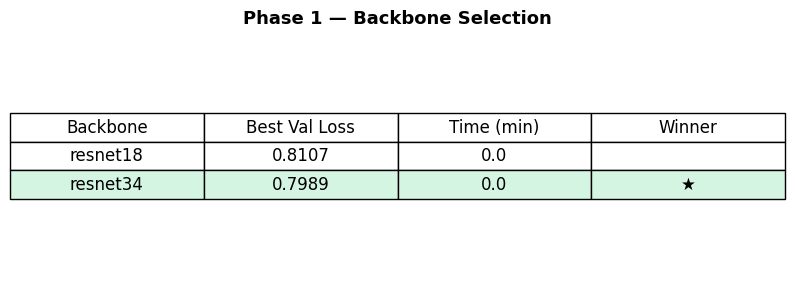

In [31]:
# ── Phase 1: Results Table ────────────────────────────────────
def _render_results_table(ax, headers, rows, winner_key, title):
    """Render a styled matplotlib table and highlight the winning row."""
    ax.axis("off")
    table = ax.table(cellText=rows, colLabels=headers, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.6)
    winner_row = next(
        (i for i, r in enumerate(rows) if r[0] == winner_key), None
    )
    if winner_row is not None:
        for j in range(len(headers)):
            table[winner_row + 1, j].set_facecolor("#d5f5e3")
    ax.set_title(title, fontweight="bold", fontsize=13)


fig, ax = plt.subplots(figsize=(8, 3))
headers = ["Backbone", "Best Val Loss", "Time (min)", "Winner"]
rows    = [
    [bb,
     f"{r['best_val_loss']:.4f}",
     f"{r['elapsed_min']:.1f}",
     "★" if bb == p1_winner else ""]
    for bb, r in phase1_results.items()
]
_render_results_table(ax, headers, rows, p1_winner, "Phase 1 — Backbone Selection")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "phase1_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Phase 2 — Skip Connection Study

Compare standard skip connections vs attention-gated mask-injected skip
connections, using the Phase 1 winning backbone.

In [32]:
# ── Phase 2: Skip Connection Study ────────────────────────────
phase2_results: Dict[str, dict] = {}

for skip_type, use_attn in [("standard", False), ("attention_mask", True)]:
    ckpt_name = f"phase2_{skip_type}.pt"
    ckpt_path = CKPT_DIR / ckpt_name
    if not ckpt_path.exists():
        ckpt_path = CKPT_SAVE_DIR / ckpt_name

    if ckpt_path.exists():
        print(f"  ✓ Loading Phase 2 checkpoint: {ckpt_path}")
        model = BoundaryAwareInpainter(
            backbone=p1_winner,
            use_attention_skip=use_attn,
            use_gated_conv=False,
            multiscale_output=False,
        ).to(DEVICE)
        state = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
        model.load_state_dict(state)
        _lm = InpaintingLossManager("base", DEVICE)
        val_losses = validate(model, val_loader, _lm)
        phase2_results[skip_type] = {
            "best_val_loss": val_losses["total"],
            "elapsed_min": 0.0,
            "history": {"train_loss": [], "val_loss": [], "lr": []},
            "ckpt_path": str(ckpt_path),
        }
        print(f"    val_loss={val_losses['total']:.4f}")
        del model, _lm
        torch.cuda.empty_cache()
    else:
        print(f"  ⚠️  Checkpoint not found — training Phase 2 for {skip_type}")
        model = BoundaryAwareInpainter(
            backbone=p1_winner,
            use_attention_skip=use_attn,
            use_gated_conv=False,
            multiscale_output=False,
        )
        result = run_experiment(
            name=f"phase2_{skip_type}",
            model=model,
            train_loader=fast_train_loader,
            val_loader=val_loader,
            loss_config="base",
            num_epochs=PHASE_FAST_EPOCHS,
            freeze_encoder_epochs=1,
            patience=PHASE_FAST_EPOCHS,
        )
        phase2_results[skip_type] = result
        del model
        torch.cuda.empty_cache()
        gc.collect()

if phase2_results:
    p2_winner = min(phase2_results, key=lambda k: phase2_results[k]["best_val_loss"])
else:
    p2_winner = "attention_mask"  # hardcoded fallback

use_attn_skip = (p2_winner == "attention_mask")
print(f"\n✓ Phase 2 Winner: {p2_winner} "
      f"(val_loss={phase2_results[p2_winner]['best_val_loss']:.4f})")

  ✓ Loading Phase 2 checkpoint: /kaggle/input/datasets/kaggleuser9205/computervision/checkpoints/phase2_standard.pt
    val_loss=0.7947
  ✓ Loading Phase 2 checkpoint: /kaggle/input/datasets/kaggleuser9205/computervision/checkpoints/phase2_attention_mask.pt
    val_loss=0.7919

✓ Phase 2 Winner: attention_mask (val_loss=0.7919)


### Phase 2 Results
Attention-gated mask-injected skip connections (`attention_mask`) vs plain identity skips. Winner carries forward into Phase 3.

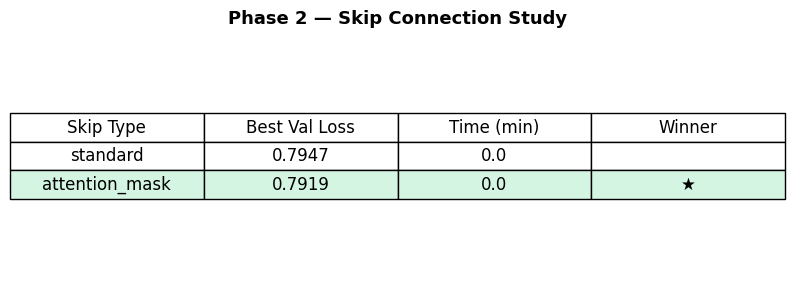

In [33]:
# ── Phase 2: Results Table ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
headers  = ["Skip Type", "Best Val Loss", "Time (min)", "Winner"]
rows     = [
    [st,
     f"{r['best_val_loss']:.4f}",
     f"{r['elapsed_min']:.1f}",
     "★" if st == p2_winner else ""]
    for st, r in phase2_results.items()
]
_render_results_table(ax, headers, rows, p2_winner, "Phase 2 — Skip Connection Study")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "phase2_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Phase 3 — Gated Convolution Study

Compare standard convolutions vs gated convolutions in the decoder.

In [34]:
# ── Phase 3: Gated Convolution Study ──────────────────────────
phase3_results: Dict[str, dict] = {}

for conv_type, use_gated in [("standard_conv", False), ("gated_conv", True)]:
    ckpt_name = f"phase3_{conv_type}.pt"
    ckpt_path = CKPT_DIR / ckpt_name
    if not ckpt_path.exists():
        ckpt_path = CKPT_SAVE_DIR / ckpt_name

    if ckpt_path.exists():
        print(f"  ✓ Loading Phase 3 checkpoint: {ckpt_path}")
        model = BoundaryAwareInpainter(
            backbone=p1_winner,
            use_attention_skip=use_attn_skip,
            use_gated_conv=use_gated,
            multiscale_output=False,
        ).to(DEVICE)
        state = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
        model.load_state_dict(state)
        _lm = InpaintingLossManager("base", DEVICE)
        val_losses = validate(model, val_loader, _lm)
        phase3_results[conv_type] = {
            "best_val_loss": val_losses["total"],
            "elapsed_min": 0.0,
            "history": {"train_loss": [], "val_loss": [], "lr": []},
            "ckpt_path": str(ckpt_path),
        }
        print(f"    val_loss={val_losses['total']:.4f}")
        del model, _lm
        torch.cuda.empty_cache()
    else:
        print(f"  ⚠️  Checkpoint not found — training Phase 3 for {conv_type}")
        model = BoundaryAwareInpainter(
            backbone=p1_winner,
            use_attention_skip=use_attn_skip,
            use_gated_conv=use_gated,
            multiscale_output=False,
        )
        result = run_experiment(
            name=f"phase3_{conv_type}",
            model=model,
            train_loader=fast_train_loader,
            val_loader=val_loader,
            loss_config="base",
            num_epochs=PHASE_FAST_EPOCHS,
            freeze_encoder_epochs=1,
            patience=PHASE_FAST_EPOCHS,
        )
        phase3_results[conv_type] = result
        del model
        torch.cuda.empty_cache()
        gc.collect()

if phase3_results:
    p3_winner = min(phase3_results, key=lambda k: phase3_results[k]["best_val_loss"])
else:
    p3_winner = "gated_conv"  # hardcoded fallback

use_gated_final = (p3_winner == "gated_conv")
print(f"\n✓ Phase 3 Winner: {p3_winner} "
      f"(val_loss={phase3_results[p3_winner]['best_val_loss']:.4f})")

# Release fast loader — no longer needed
del fast_train_loader
torch.cuda.empty_cache()
gc.collect()

  ✓ Loading Phase 3 checkpoint: /kaggle/input/datasets/kaggleuser9205/computervision/checkpoints/phase3_standard_conv.pt
    val_loss=0.7951
  ✓ Loading Phase 3 checkpoint: /kaggle/input/datasets/kaggleuser9205/computervision/checkpoints/phase3_gated_conv.pt
    val_loss=0.7914

✓ Phase 3 Winner: gated_conv (val_loss=0.7914)


2784

### Phase 3 Results
Gated decoder convolutions vs standard conv-BN-ELU blocks. Architecture decision is locked in before Phase 4.

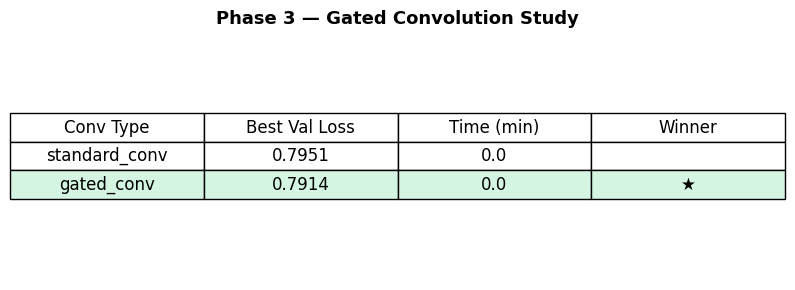


Architecture decision summary:
  Backbone:   resnet34
  Skip type:  attention_mask  (use_attention_skip=True)
  Conv type:  gated_conv  (use_gated_conv=True)


In [35]:
# ── Phase 3: Results Table ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
headers  = ["Conv Type", "Best Val Loss", "Time (min)", "Winner"]
rows     = [
    [ct,
     f"{r['best_val_loss']:.4f}",
     f"{r['elapsed_min']:.1f}",
     "★" if ct == p3_winner else ""]
    for ct, r in phase3_results.items()
]
_render_results_table(ax, headers, rows, p3_winner, "Phase 3 — Gated Convolution Study")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "phase3_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nArchitecture decision summary:")
print(f"  Backbone:   {p1_winner}")
print(f"  Skip type:  {p2_winner}  (use_attention_skip={use_attn_skip})")
print(f"  Conv type:  {p3_winner}  (use_gated_conv={use_gated_final})")

## 12. Phase 4 — Loss Ablation Study (Full Dataset, 30 Epochs)

Five experiments on the full training set:
- **L0_base:** hole + valid + perceptual
- **L1_boundary_uniform:** + uniform boundary loss
- **L2_boundary_grad:** + gradient-weighted boundary loss
- **L3_spectral_only:** + spectral coherence loss
- **L4_full_method:** all losses + multi-scale supervision

In [ ]:
# ── Phase 4: Full Dataset Loaders & Loss Ablation ──────────────────────────
# Architecture winners from Phases 1-3
BEST_BACKBONE      = p1_winner
USE_GATED_CONV     = use_gated_final
USE_ATTENTION_SKIP = use_attn_skip

print("Phase 4 Architecture Configuration:")
print(f"  Backbone:       {BEST_BACKBONE}")
print(f"  Gated Conv:     {USE_GATED_CONV}")
print(f"  Attention Skip: {USE_ATTENTION_SKIP}")

# ── Pre-cache training masks to eliminate CPU bottleneck ──────────────
# Without this, on-the-fly mask generation starves the GPU (0% GPU, 100% CPU).
# Pre-cached .npy masks load instantly → GPU stays at 80%+.
print("\nPre-caching training masks ...")
_train_mask_dir = Path("./cached_masks/train")
_train_mask_dir.mkdir(parents=True, exist_ok=True)

_N_TRAIN_MASKS = 2000  # masks are cycled over training images

_existing_train_masks = sorted(_train_mask_dir.glob("train_*.npy"))
if len(_existing_train_masks) >= _N_TRAIN_MASKS:
    print(f"  Already cached: {len(_existing_train_masks)} masks")
    _train_mask_paths = _existing_train_masks[:_N_TRAIN_MASKS]
else:
    _saved_state = np.random.get_state()
    np.random.seed(SEED + 777)
    _train_mask_paths = []
    for _i in tqdm(range(_N_TRAIN_MASKS), desc="Caching train masks"):
        _mp = _train_mask_dir / f"train_{_i:04d}.npy"
        if not _mp.exists():
            np.save(_mp, generate_freeform_mask(IMG_SIZE, IMG_SIZE))
        _train_mask_paths.append(_mp)
    np.random.set_state(_saved_state)

# Rebuild train_ds with fixed masks so DataLoader doesn't block on CPU
train_ds = InpaintingDataset(
    places_splits["train"],
    fixed_mask_paths=_train_mask_paths,
)
print(f"  ✓ train_ds rebuilt with {_N_TRAIN_MASKS} pre-cached masks")

# ── Full dataset loaders ─────────────────────────────────────────────
print("\nBuilding full dataset loaders...")
full_train_loader = make_loader(train_ds, shuffle=True, drop_last=True)
full_val_loader   = make_loader(val_ds, shuffle=False)
print(f"  train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}")

# ── Phase 4 experiment configuration ─────────────────────────────────
phase4_configs: Dict[str, Dict] = {
    "L0_base":             {"loss_config": "base",             "multiscale": False},
    "L1_boundary_uniform": {"loss_config": "boundary_uniform", "multiscale": False},
    "L2_boundary_grad":    {"loss_config": "boundary_grad",    "multiscale": False},
    "L3_spectral_only":    {"loss_config": "spectral_only",    "multiscale": False},
    "L4_full_method":      {"loss_config": "full",             "multiscale": True},
}

# ── Timing budget ────────────────────────────────────────────────────
# Kaggle limit: 12 hrs. With pre-cached masks, ~3-5 min/epoch on T4.
# 10 epochs × 4 ablation + 15 epochs × L4 ≈ 4-6 hrs total.
_EPOCHS_ABLATION = 10
_EPOCHS_FULL     = 15
_PATIENCE_ABL    = 3
_PATIENCE_FULL   = 5

phase4_results:   Dict[str, dict] = {}
phase4_histories: Dict[str, dict] = {}

for exp_name, cfg in phase4_configs.items():
    full_exp_name = f"phase4_{exp_name}"
    loss_config   = cfg["loss_config"]
    is_multiscale = cfg["multiscale"]

    # Check if checkpoint already exists (read-only dataset or writable dir)
    ckpt_path = CKPT_DIR / f"{full_exp_name}.pt"
    if not ckpt_path.exists():
        ckpt_path = CKPT_SAVE_DIR / f"{full_exp_name}.pt"

    if ckpt_path.exists():
        print(f"\n  ✓ {full_exp_name} checkpoint exists ({ckpt_path}) — skipping training")
        phase4_results[exp_name] = {
            "name": full_exp_name,
            "best_val_loss": float("nan"),
            "elapsed_min": 0.0,
            "ckpt_path": str(ckpt_path),
        }
        phase4_histories[exp_name] = {"train_loss": [], "val_loss": [], "lr": []}
        continue

    is_full  = (exp_name == "L4_full_method")
    n_epochs = _EPOCHS_FULL if is_full else _EPOCHS_ABLATION
    pat      = _PATIENCE_FULL if is_full else _PATIENCE_ABL

    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {full_exp_name}  |  loss: {loss_config}  |  epochs: {n_epochs}  |  patience: {pat}")
    print(f"{'='*60}")

    model = BoundaryAwareInpainter(
        backbone=BEST_BACKBONE,
        use_gated_conv=USE_GATED_CONV,
        use_attention_skip=USE_ATTENTION_SKIP,
        multiscale_output=is_multiscale,
    ).to(DEVICE)

    result = run_experiment(
        name=full_exp_name,
        model=model,
        train_loader=full_train_loader,
        val_loader=full_val_loader,
        loss_config=loss_config,
        num_epochs=n_epochs,
        freeze_encoder_epochs=2,
        patience=pat,
    )

    phase4_results[exp_name]   = result
    phase4_histories[exp_name] = result.get("history", {"train_loss": [], "val_loss": [], "lr": []})

    # Confirm checkpoint saved
    _saved_ckpt = CKPT_SAVE_DIR / f"{full_exp_name}.pt"
    if _saved_ckpt.exists():
        _sz = _saved_ckpt.stat().st_size / 1e6
        print(f"  ✓ Checkpoint confirmed: {_saved_ckpt} ({_sz:.1f} MB)")
    else:
        print(f"    WARNING: Checkpoint NOT found at {_saved_ckpt}!")

    del model
    torch.cuda.empty_cache()
    gc.collect()

print("\n✓ Phase 4 training complete.")
print("\nAll checkpoints:")
for _f in sorted(CKPT_SAVE_DIR.glob("*.pt")):
    print(f"  {_f.name}  ({_f.stat().st_size/1e6:.1f} MB)")

Phase 4 Architecture Configuration:
  Backbone:       resnet34
  Gated Conv:     True
  Attention Skip: True

Pre-caching training masks ...


Caching train masks:   0%|          | 0/2000 [00:00<?, ?it/s]

  ✓ train_ds rebuilt with 2000 pre-cached masks

Building full dataset loaders...
  train=22379 | val=4795 | test=4797

  ✓ phase4_L0_base checkpoint exists (/kaggle/input/datasets/kaggleuser9205/computervision/checkpoints/phase4_L0_base.pt) — skipping training

EXPERIMENT: phase4_L1_boundary_uniform  |  loss: boundary_uniform  |  epochs: 10  |  patience: 3

EXPERIMENT: phase4_L1_boundary_uniform
  Loss:          boundary_uniform
  Epochs (max):  10
  Freeze enc:    first 2 epochs
  Patience:      3
  Epoch   1/10 | train=1.2914  val=1.1117 | lr=1.50e-04 | 728s
  Epoch   2/10 | train=1.0710  val=1.0490 | lr=3.00e-04 | 1299s
  [Epoch 2] Encoder unfrozen.
  Epoch   3/10 | train=0.9758  val=0.9265 | lr=3.00e-04 | 1922s
  Epoch   4/10 | train=0.9191  val=0.9355 | lr=2.89e-04 | 2524s
  Epoch   5/10 | train=0.8897  val=0.9033 | lr=2.56e-04 | 3131s
  Epoch   6/10 | train=0.8633  val=0.8767 | lr=2.08e-04 | 3741s
  Epoch   7/10 | train=0.8311  val=0.8786 | lr=1.50e-04 | 4342s
  Epoch   8/10 | t

## 13. Phase 4 — Full Evaluation on Test Set

In [ ]:
# ── 13.1 Evaluate All Phase 4 Models on Test Set ──────────────
test_loader = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
phase4_eval: Dict[str, dict] = {}

for exp_name, cfg in phase4_configs.items():
    print(f"\nEvaluating {exp_name} ...")

    full_exp_name = f"phase4_{exp_name}"
    # Try both checkpoint directories
    ckpt_path = CKPT_DIR / f"{full_exp_name}.pt"
    if not ckpt_path.exists():
        ckpt_path = CKPT_SAVE_DIR / f"{full_exp_name}.pt"

    if not ckpt_path.exists():
        print(f"    Checkpoint not found: {full_exp_name}.pt — skipping.")
        continue

    model = BoundaryAwareInpainter(
        backbone=BEST_BACKBONE,
        use_attention_skip=USE_ATTENTION_SKIP,
        use_gated_conv=USE_GATED_CONV,
        multiscale_output=cfg["multiscale"],
    ).to(DEVICE)

    model.load_state_dict(
        torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
    )
    model.eval()

    global_metrics, bin_metrics = evaluate_model(model, test_loader)
    phase4_eval[exp_name] = {"global": global_metrics, "bins": bin_metrics}

    print(
        f"  PSNR={global_metrics['psnr']:.2f}  "
        f"SSIM={global_metrics['ssim']:.4f}  "
        f"Hole-MAE={global_metrics['hole_mae']:.4f}  "
        f"Boundary-MAE={global_metrics['boundary_mae']:.4f}  "
        f"Spectral={global_metrics['spectral_coherence']:.4f}"
    )

    del model
    torch.cuda.empty_cache()
    gc.collect()

print("\nAll Phase 4 evaluations complete.")


Evaluating L0_base ...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
  LPIPS init failed (<urlopen error [Errno -3] Temporary failure in name resolution>); skipping LPIPS metric.


Evaluating:   0%|          | 0/75 [00:00<?, ?it/s]

  PSNR=20.37  SSIM=0.7150  Hole-MAE=0.1034  Boundary-MAE=0.0319  Spectral=0.9839

Evaluating L1_boundary_uniform ...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
  LPIPS init failed (<urlopen error [Errno -3] Temporary failure in name resolution>); skipping LPIPS metric.


Evaluating:   0%|          | 0/75 [00:00<?, ?it/s]

  PSNR=20.09  SSIM=0.7099  Hole-MAE=0.1076  Boundary-MAE=0.0320  Spectral=0.9833

Evaluating L2_boundary_grad ...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
  LPIPS init failed (<urlopen error [Errno -3] Temporary failure in name resolution>); skipping LPIPS metric.


...

  PSNR=20.07  SSIM=0.7081  Hole-MAE=0.1081  Boundary-MAE=0.0330  Spectral=0.9831

Evaluating L3_spectral_only ...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
  LPIPS init failed (<urlopen error [Errno -3] Temporary failure in name resolution>); skipping LPIPS metric.


Evaluating:   0%|          | 0/75 [00:00<?, ?it/s]

  PSNR=20.08  SSIM=0.7118  Hole-MAE=0.1073  Boundary-MAE=0.0320  Spectral=0.9834

Evaluating L4_full_method ...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
  LPIPS init failed (<urlopen error [Errno -3] Temporary failure in name resolution>); skipping LPIPS metric.


Evaluating:   0%|          | 0/75 [00:00<?, ?it/s]

  PSNR=20.02  SSIM=0.7132  Hole-MAE=0.1078  Boundary-MAE=0.0311  Spectral=0.9836

All Phase 4 evaluations complete.


### 13.2 Global Ablation Table
Summary of all five loss configurations evaluated on the held-out test set. Columns show all five metrics; the best value per column is highlighted.

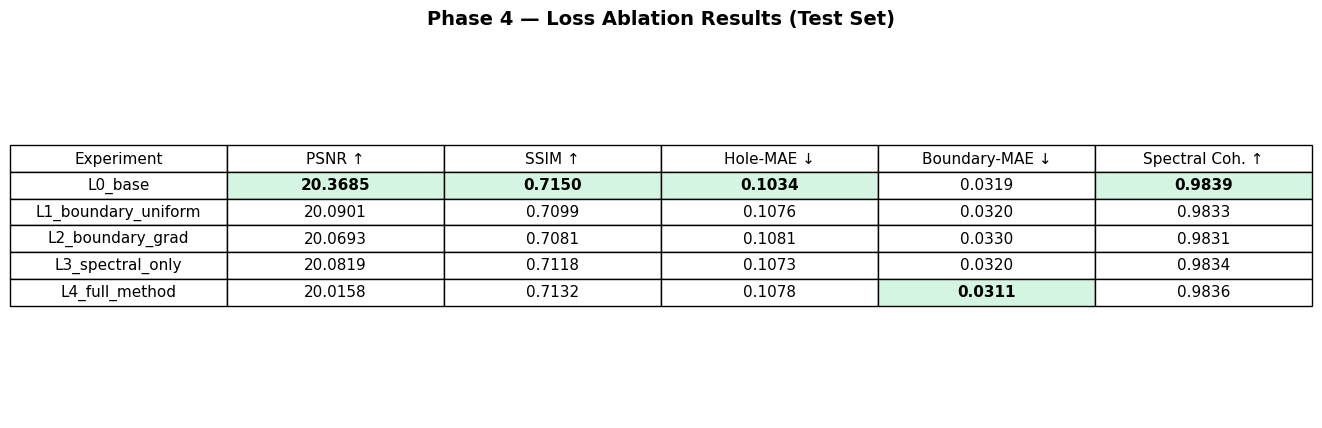

In [38]:
# ── 13.2 Global Ablation Table ────────────────────────────────
metric_names   = ["psnr", "ssim", "hole_mae", "boundary_mae", "spectral_coherence"]
display_names  = ["PSNR ↑", "SSIM ↑", "Hole-MAE ↓", "Boundary-MAE ↓", "Spectral Coh. ↑"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

headers = ["Experiment"] + display_names
rows    = []
for exp_name in phase4_eval:   # only experiments that completed
    g   = phase4_eval[exp_name]["global"]
    row = [exp_name] + [f"{g.get(m, float('nan')):.4f}" for m in metric_names]
    rows.append(row)

table = ax.table(cellText=rows, colLabels=headers, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.6)

# Highlight the best cell in each metric column
for col_idx, m in enumerate(metric_names, start=1):
    vals = [phase4_eval[e]["global"].get(m, float("nan")) for e in phase4_eval]
    best_idx = int(np.nanargmin(vals)) if "mae" in m else int(np.nanargmax(vals))
    table[best_idx + 1, col_idx].set_facecolor("#d5f5e3")
    table[best_idx + 1, col_idx].set_text_props(fontweight="bold")

plt.title("Phase 4 — Loss Ablation Results (Test Set)",
          fontweight="bold", fontsize=14)
plt.savefig(RESULTS_DIR / "phase4_ablation_table.png", dpi=150, bbox_inches="tight")
plt.show()

### 13.3 Stratified Results by Mask Difficulty
Breaks down PSNR, SSIM, Hole-MAE, Boundary-MAE, and Spectral Coherence across the four mask difficulty bins. Reveals how each loss configuration behaves under increasing inpainting difficulty.

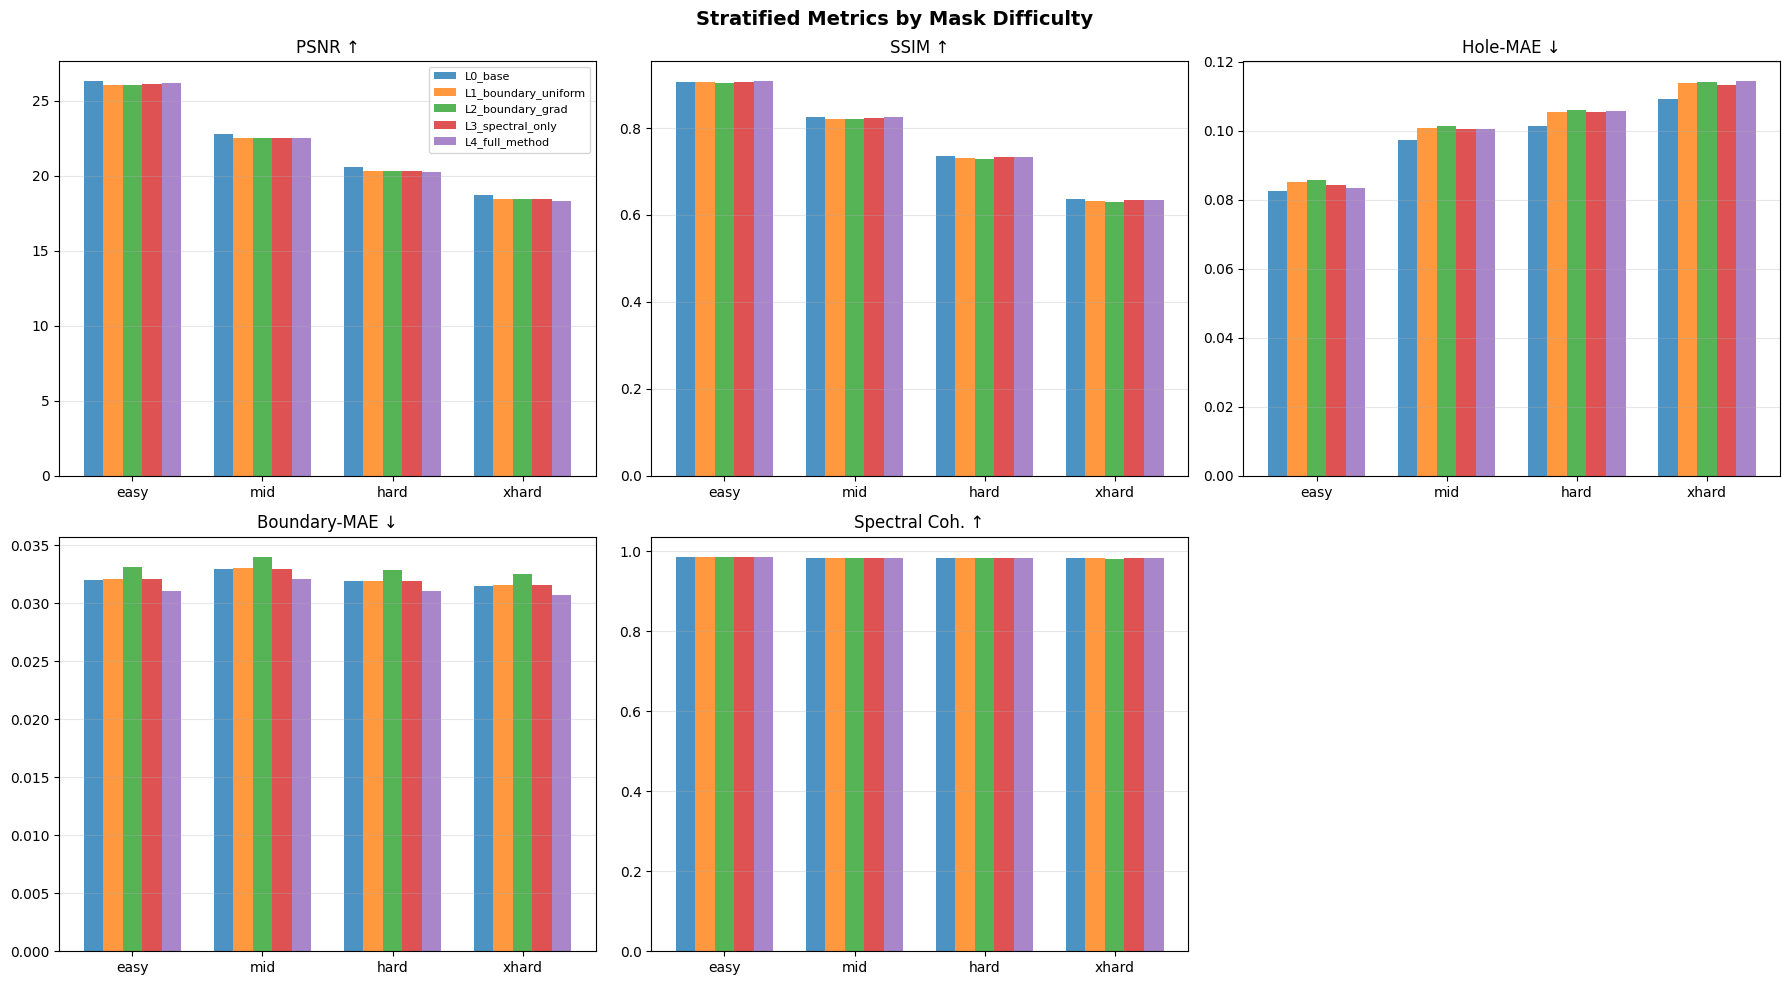

In [39]:
# ── 13.3 Stratified Results by Mask Difficulty Bin ────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Stratified Metrics by Mask Difficulty", fontsize=14, fontweight="bold")

plot_metrics = ["psnr", "ssim", "hole_mae", "boundary_mae", "spectral_coherence"]
plot_titles  = ["PSNR ↑", "SSIM ↑", "Hole-MAE ↓", "Boundary-MAE ↓", "Spectral Coh. ↑"]
bin_names    = list(MASK_BINS.keys())
x     = np.arange(len(bin_names))
width = 0.15

for ax_idx, (metric, title) in enumerate(zip(plot_metrics, plot_titles)):
    ax = axes.flat[ax_idx]
    for i, exp_name in enumerate(phase4_eval):
        vals = [
            phase4_eval[exp_name]["bins"].get(bn, {}).get(metric, 0)
            for bn in bin_names
        ]
        ax.bar(x + i * width, vals, width,
               label=exp_name if ax_idx == 0 else "", alpha=0.8)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(bin_names)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

axes.flat[0].legend(fontsize=8, loc="upper right")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "phase4_stratified.png", dpi=150, bbox_inches="tight")
plt.show()

### 13.4 Training Curves
Train and validation loss trajectories for all Phase 4 experiments. Useful for diagnosing overfitting and confirming that early stopping engaged at reasonable points.

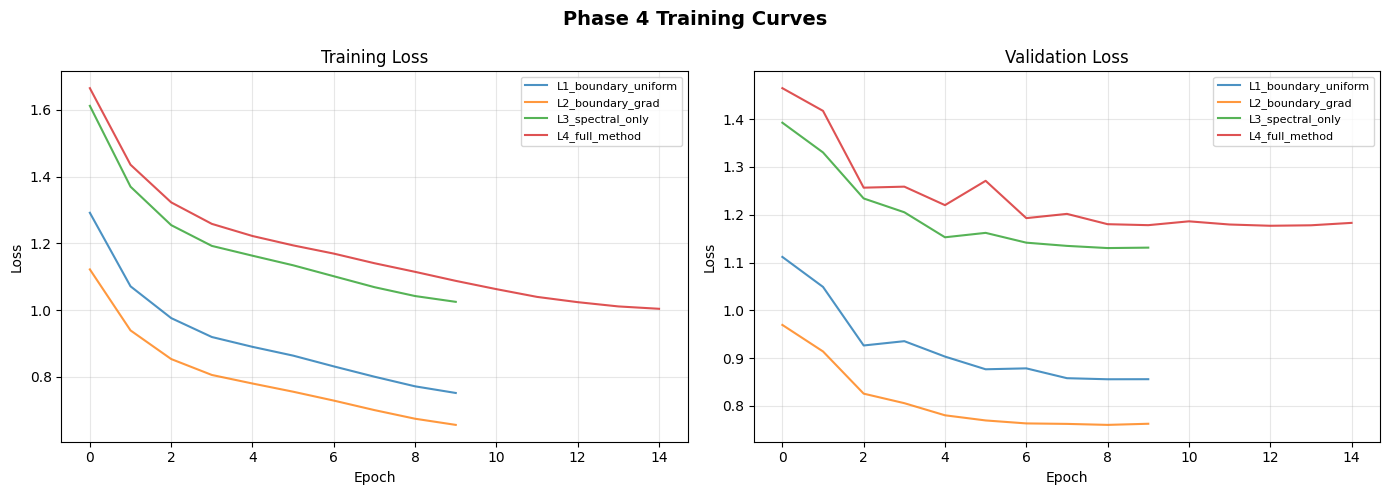

In [40]:
# ── 13.4 Training Curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 4 Training Curves", fontsize=14, fontweight="bold")

has_curves = False
for exp_name, h in phase4_histories.items():
    if len(h.get("train_loss", [])) > 0:
        has_curves = True
        axes[0].plot(h["train_loss"], label=exp_name, alpha=0.8)
    if len(h.get("val_loss", [])) > 0:
        axes[1].plot(h["val_loss"], label=exp_name, alpha=0.8)

if not has_curves:
    axes[0].text(0.5, 0.5, "No training history\n(loaded from checkpoints)",
                 transform=axes[0].transAxes, ha="center", va="center", fontsize=12)
    axes[1].text(0.5, 0.5, "No training history\n(loaded from checkpoints)",
                 transform=axes[1].transAxes, ha="center", va="center", fontsize=12)

for ax, title in zip(axes, ["Training Loss", "Validation Loss"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    if has_curves:
        ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "phase4_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Qualitative Results & Visualisations

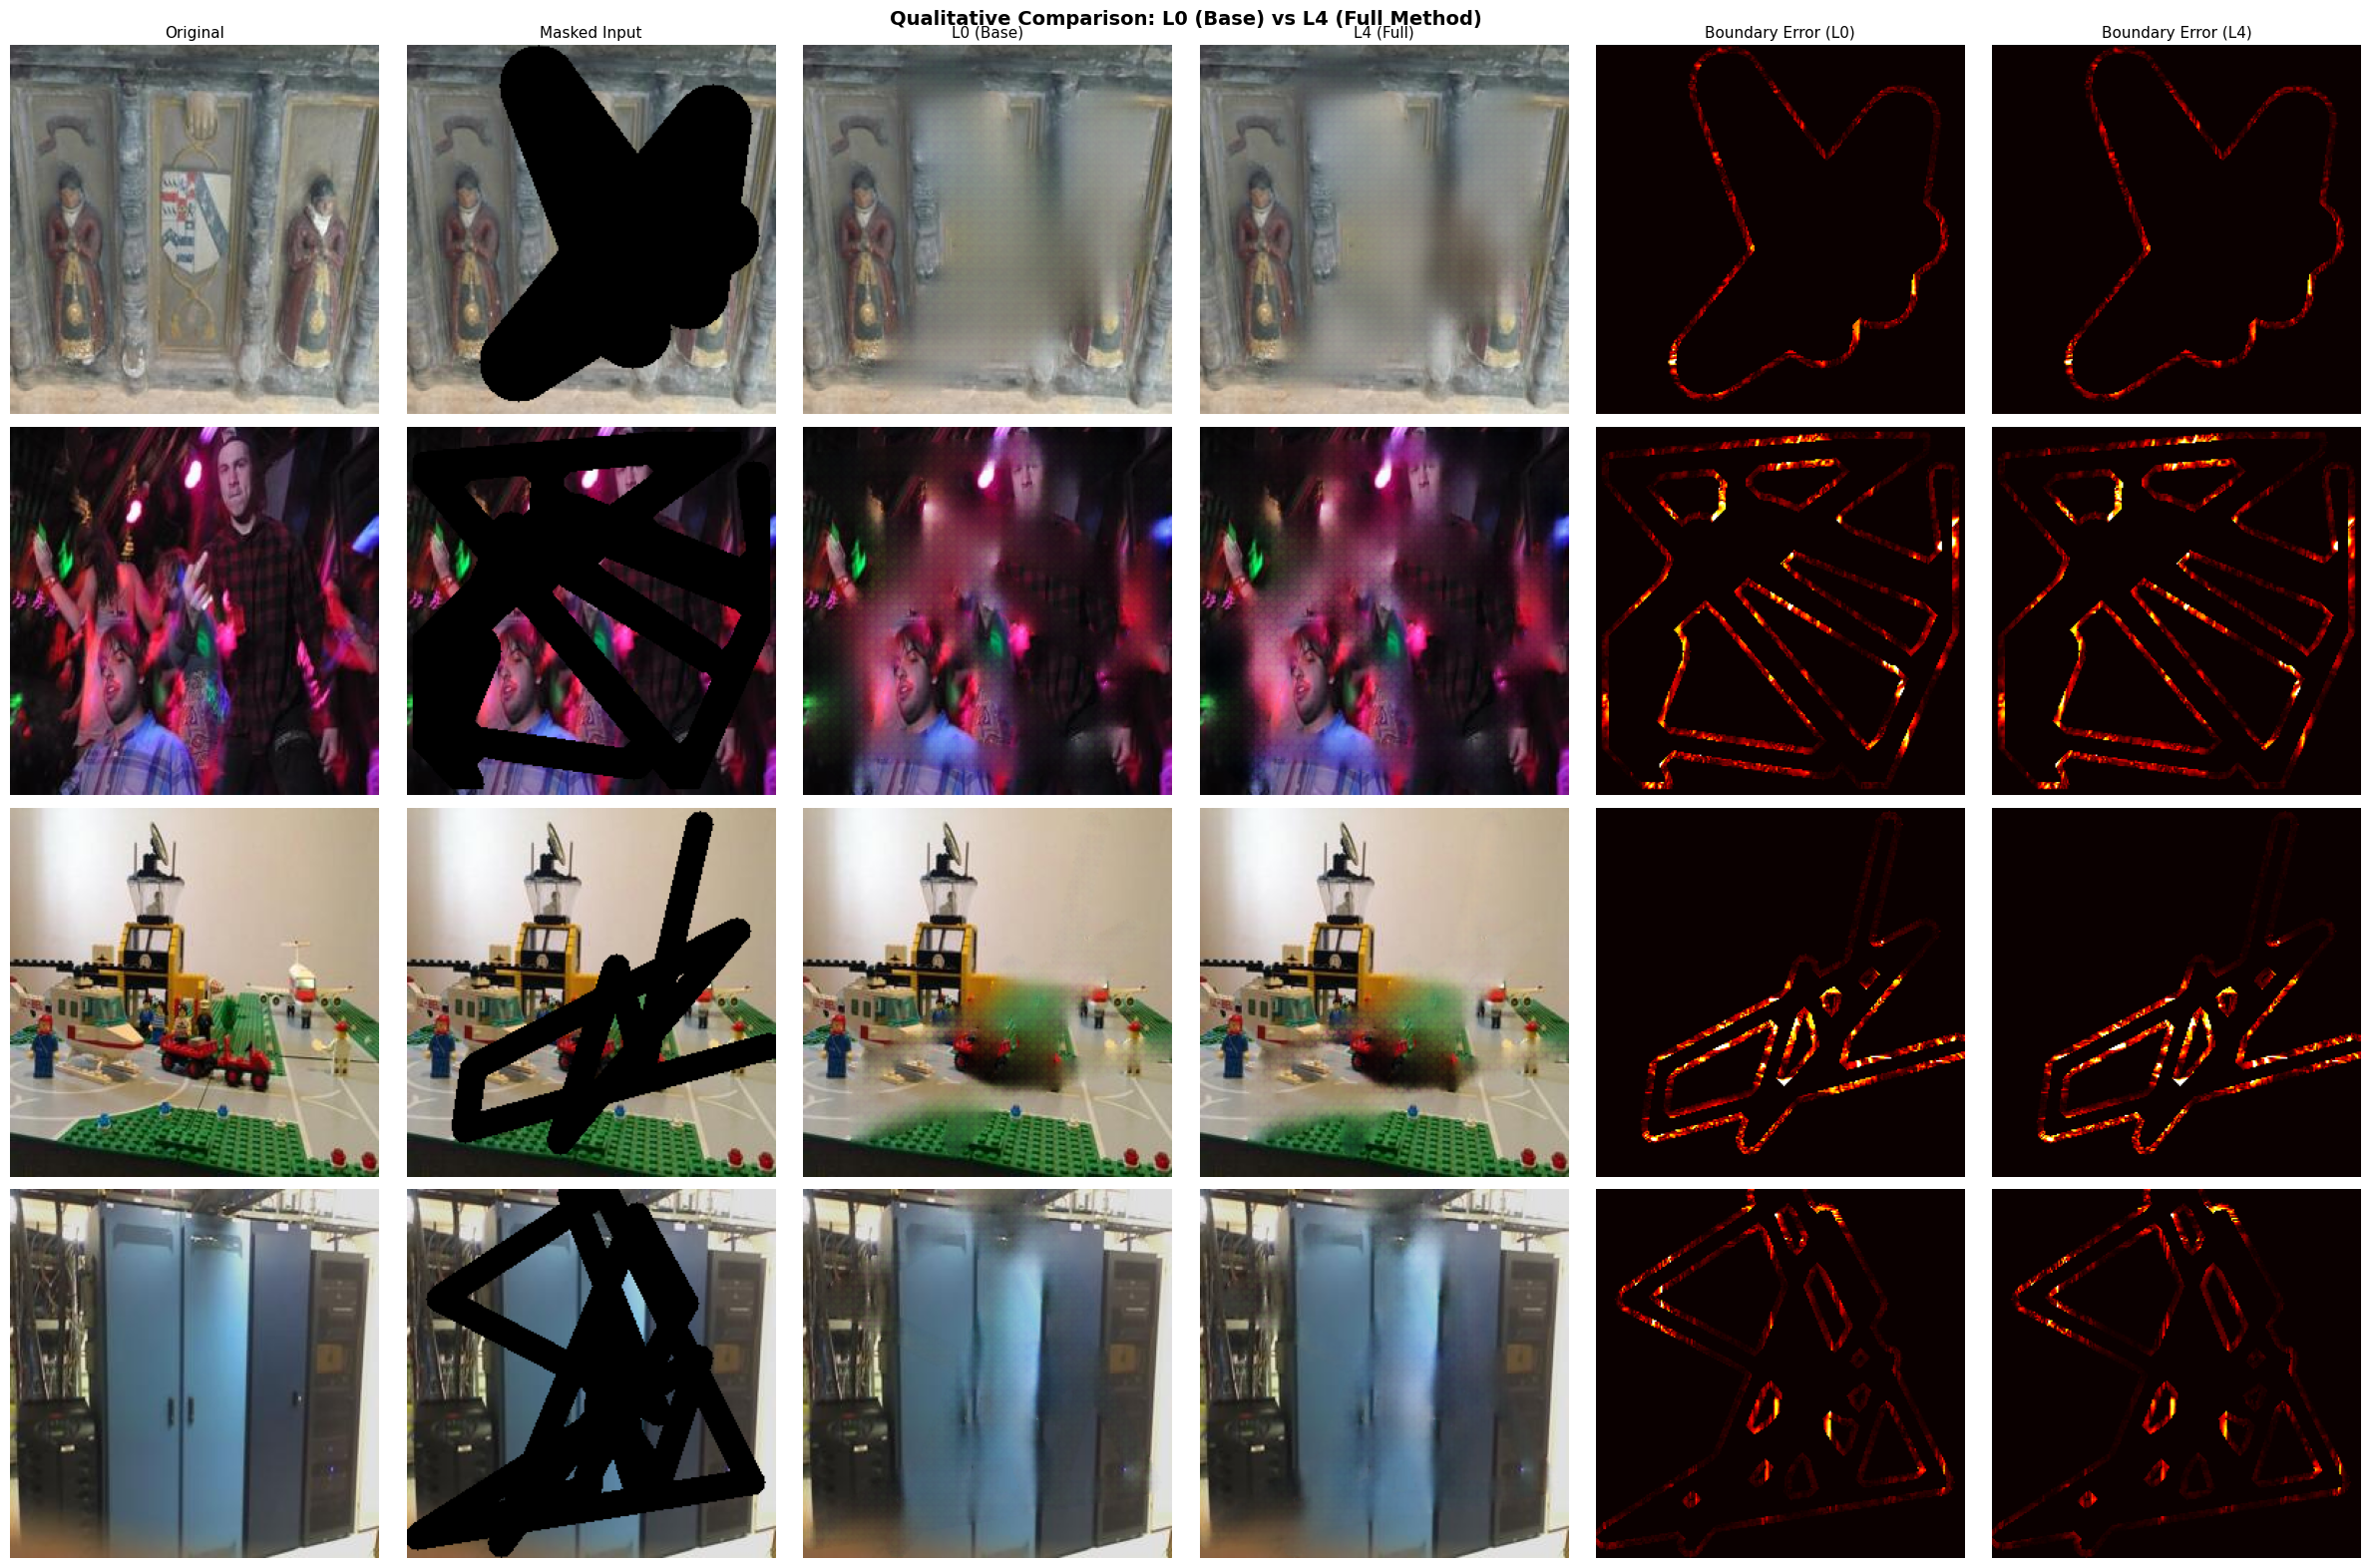

In [41]:
# ── 14.1 Helper: Load a Phase 4 Checkpoint ────────────────────
def load_phase4_model(exp_name: str) -> nn.Module:
    """Instantiate and load the best checkpoint for a Phase 4 experiment.

    Raises FileNotFoundError if the checkpoint does not exist.
    Automatically sets multiscale_output=True for L4/full experiments.
    """
    cfg = phase4_configs[exp_name]
    full_exp_name = f"phase4_{exp_name}"

    # Try both checkpoint directories
    ckpt = CKPT_DIR / f"{full_exp_name}.pt"
    if not ckpt.exists():
        ckpt = CKPT_SAVE_DIR / f"{full_exp_name}.pt"
    if not ckpt.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {full_exp_name}.pt\n"
            f"Checked: {CKPT_DIR} and {CKPT_SAVE_DIR}\n"
            "Did Phase 4 training complete successfully?"
        )

    # L4 / full must use multiscale_output=True
    use_ms = cfg["multiscale"] or "L4" in exp_name or "full" in exp_name

    model = BoundaryAwareInpainter(
        backbone=BEST_BACKBONE,
        use_attention_skip=USE_ATTENTION_SKIP,
        use_gated_conv=USE_GATED_CONV,
        multiscale_output=use_ms,
    ).to(DEVICE)
    model.load_state_dict(
        torch.load(ckpt, map_location=DEVICE, weights_only=True)
    )
    model.eval()
    return model


# ── 14.2 Qualitative Comparison Grid ─────────────────────────
model_l0 = load_phase4_model("L0_base")
model_l4 = load_phase4_model("L4_full_method")

test_iter = iter(make_loader(test_ds, batch_size=8, shuffle=False))
test_imgs, test_masks, test_bands = next(test_iter)
test_imgs  = test_imgs.to(DEVICE)
test_masks = test_masks.to(DEVICE)
test_bands = test_bands.to(DEVICE)

masked_input = test_imgs * (1.0 - test_masks)

with torch.no_grad():
    with _autocast_ctx():
        pred_l0 = model_l0(masked_input, test_masks)["output"].float()
        pred_l4 = model_l4(masked_input, test_masks)["output"].float()

comp_l0 = test_imgs * (1.0 - test_masks) + pred_l0 * test_masks
comp_l4 = test_imgs * (1.0 - test_masks) + pred_l4 * test_masks
err_l0  = torch.abs(test_imgs - comp_l0) * test_bands
err_l4  = torch.abs(test_imgs - comp_l4) * test_bands

n_show = 4
col_titles = [
    "Original", "Masked Input", "L0 (Base)", "L4 (Full)",
    "Boundary Error (L0)", "Boundary Error (L4)",
]

fig, axes = plt.subplots(n_show, 6, figsize=(24, n_show * 4))
for row in range(n_show):
    items = [
        test_imgs[row].cpu(), masked_input[row].cpu(),
        comp_l0[row].cpu(),   comp_l4[row].cpu(),
        err_l0[row].cpu(),    err_l4[row].cpu(),
    ]
    for col, img_t in enumerate(items):
        arr = img_t.permute(1, 2, 0).numpy().clip(0, 1)
        if col >= 4:   # error maps
            axes[row, col].imshow(arr.mean(axis=2), cmap="hot", vmin=0, vmax=0.3)
        else:
            axes[row, col].imshow(arr)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=11)

plt.suptitle("Qualitative Comparison: L0 (Base) vs L4 (Full Method)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "qualitative_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

del model_l0, model_l4
torch.cuda.empty_cache()

### 14.3 Failure Case Analysis
The 12 test samples on which L4 produces the highest Boundary-MAE are visualised side-by-side (input, prediction, ground truth). Useful for understanding where spectral supervision still struggles.

Finding failure cases:   0%|          | 0/300 [00:00<?, ?it/s]

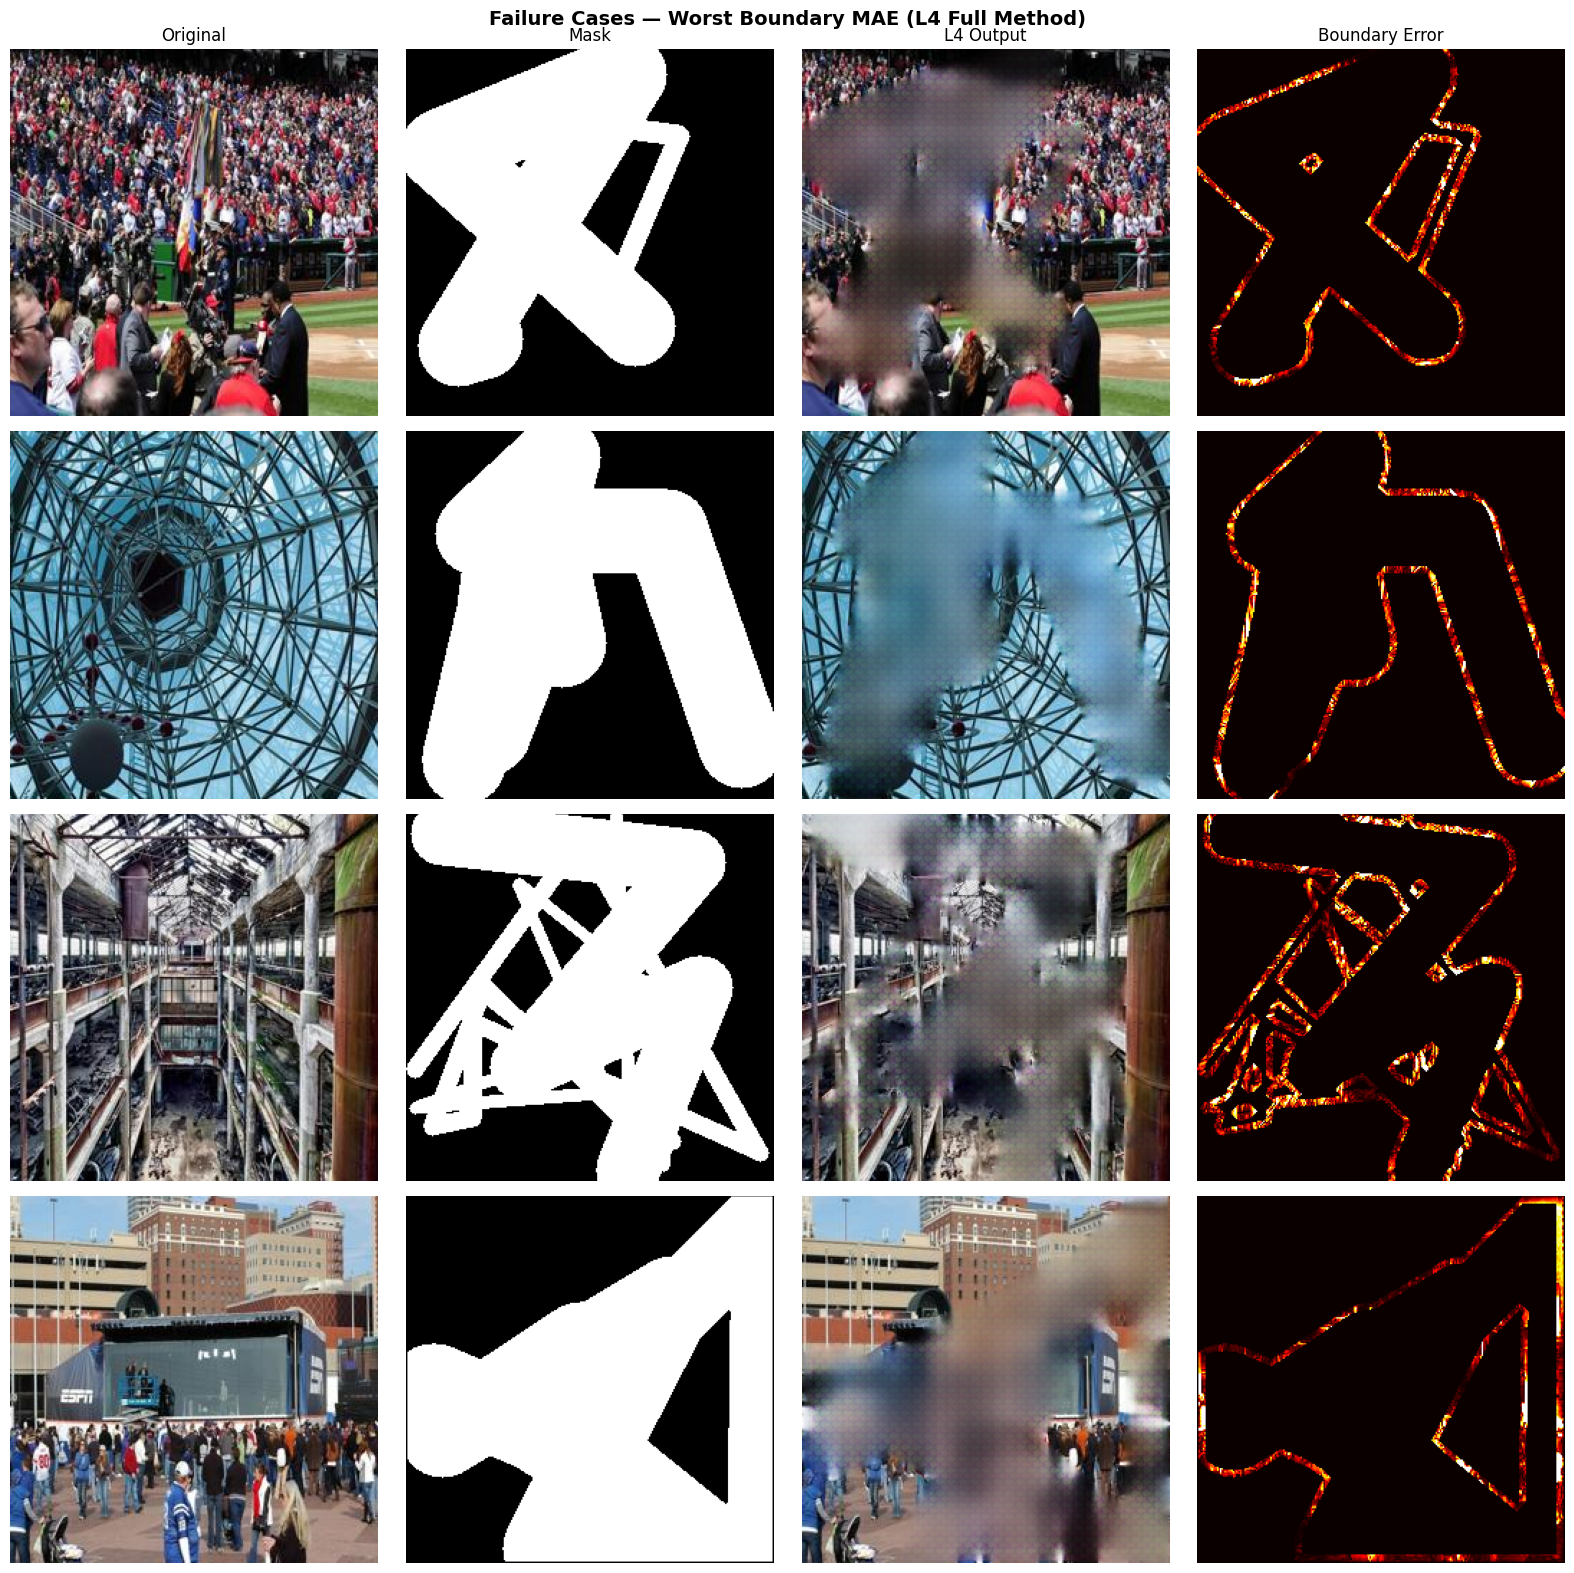

In [42]:
# ── 14.3 Failure Case Analysis ────────────────────────────────
model_l4  = load_phase4_model("L4_full_method")
worst_cases: list = []

with torch.no_grad():
    for images, masks, boundaries in tqdm(
        make_loader(test_ds, batch_size=16, shuffle=False),
        desc="Finding failure cases",
    ):
        images     = images.to(DEVICE)
        masks      = masks.to(DEVICE)
        boundaries = boundaries.to(DEVICE)
        masked_input = images * (1.0 - masks)

        with _autocast_ctx():
            pred = model_l4(masked_input, masks)["output"].float()
        comp = images * (1.0 - masks) + pred * masks

        for i in range(images.shape[0]):
            band = boundaries[i, 0].cpu().numpy()
            if band.sum() < 10:
                continue
            err    = torch.abs(images[i] - comp[i]).cpu().numpy()
            # err shape: (3, H, W); band shape: (H, W)
            # mean over channel dim first, then select band pixels
            err_mean = err.mean(axis=0)           # (H, W)
            bmae     = float(err_mean[band > 0.5].mean())
            worst_cases.append((
                bmae, images[i].cpu(), masks[i].cpu(),
                comp[i].cpu(), boundaries[i].cpu(),
            ))

worst_cases.sort(key=lambda x: -x[0])

n_rows = min(4, len(worst_cases))
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 4))
fig.suptitle("Failure Cases — Worst Boundary MAE (L4 Full Method)",
             fontsize=14, fontweight="bold")
col_titles = ["Original", "Mask", "L4 Output", "Boundary Error"]

for row in range(n_rows):
    bmae, orig, mask, comp_t, band_t = worst_cases[row]
    err = torch.abs(orig - comp_t) * band_t

    for col, (img_t, cmap) in enumerate([
        (orig,                           None),
        (mask[0:1].expand(3, -1, -1),   "gray"),
        (comp_t,                         None),
        (err,                            "hot"),
    ]):
        arr = img_t.permute(1, 2, 0).numpy().clip(0, 1)
        if cmap == "hot":
            axes[row, col].imshow(arr.mean(axis=2), cmap="hot", vmin=0, vmax=0.4)
        elif cmap == "gray":
            axes[row, col].imshow(arr[:, :, 0], cmap="gray")
        else:
            axes[row, col].imshow(arr)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(col_titles[col])
    axes[row, 0].set_ylabel(f"BMAE={bmae:.4f}", fontsize=10,
                            rotation=0, labelpad=60, va="center")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "failure_cases.png", dpi=150, bbox_inches="tight")
plt.show()

del model_l4
torch.cuda.empty_cache()

### 14.4 Boundary Error Distribution: L0 vs L4
Histograms of per-sample Boundary-MAE across the test set for the baseline (L0) and full method (L4), confirming the distributional shift toward lower boundary error.

Error dist (L0_base):   0%|          | 0/150 [00:00<?, ?it/s]

Error dist (L4_full_method):   0%|          | 0/150 [00:00<?, ?it/s]

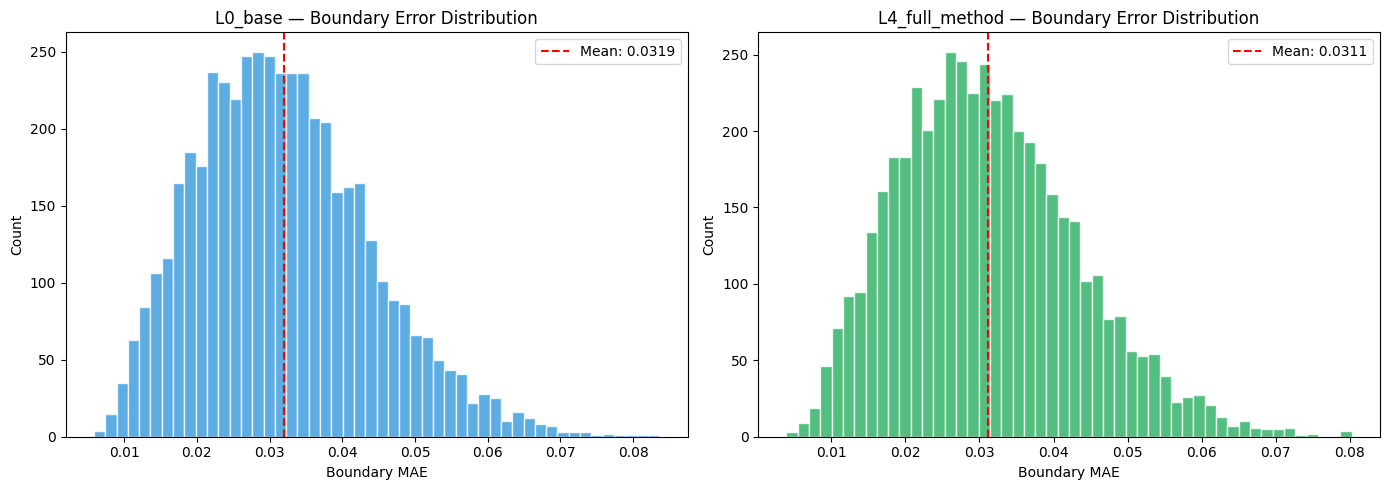

In [43]:
# ── 14.4 Boundary Error Distribution: L0 vs L4 ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, exp_name in enumerate(["L0_base", "L4_full_method"]):
    model = load_phase4_model(exp_name)
    bmaes: List[float] = []

    with torch.no_grad():
        for images, masks, boundaries in tqdm(
            make_loader(test_ds, batch_size=32, shuffle=False),
            desc=f"Error dist ({exp_name})", leave=False,
        ):
            images     = images.to(DEVICE)
            masks      = masks.to(DEVICE)
            boundaries = boundaries.to(DEVICE)
            masked_input = images * (1.0 - masks)

            with _autocast_ctx():
                pred = model(masked_input, masks)["output"].float()
            comp = images * (1.0 - masks) + pred * masks

            for i in range(images.shape[0]):
                band = boundaries[i, 0].cpu().numpy()
                if band.sum() < 10:
                    continue
                err_mean = torch.abs(images[i] - comp[i]).cpu().numpy().mean(axis=0)
                bmaes.append(float(err_mean[band > 0.5].mean()))

    del model
    torch.cuda.empty_cache()

    color = "#3498db" if ax_idx == 0 else "#27ae60"
    label = exp_name
    axes[ax_idx].hist(bmaes, bins=50, color=color, alpha=0.8, edgecolor="white")
    axes[ax_idx].set_xlabel("Boundary MAE")
    axes[ax_idx].set_ylabel("Count")
    axes[ax_idx].set_title(f"{label} — Boundary Error Distribution")
    axes[ax_idx].axvline(
        np.mean(bmaes), color="red", ls="--",
        label=f"Mean: {np.mean(bmaes):.4f}",
    )
    axes[ax_idx].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Cross-Domain Evaluation (CelebA-HQ)

Zero-shot evaluation of L0 vs L4 on CelebA-HQ

In [44]:
# ── 15.1 CelebA-HQ Zero-Shot Evaluation ──────────────────────
cross_domain_results: Dict[str, dict] = {}

if not CELEBA_AVAILABLE:
    print("⚠️  CelebA-HQ not available — skipping cross-domain evaluation.")
else:
    celeba_test_ds     = InpaintingDataset(
        celeba_splits["test"], fixed_mask_paths=test_mask_paths
    )
    celeba_test_loader = make_loader(celeba_test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # Zero-shot L0
    print("Zero-shot L0 on CelebA-HQ ...")
    model_l0         = load_phase4_model("L0_base")
    g_l0, _          = evaluate_model(model_l0, celeba_test_loader, max_batches=20)
    cross_domain_results["L0_zeroshot"] = g_l0
    print(f"  PSNR={g_l0['psnr']:.2f}  SSIM={g_l0['ssim']:.4f}  "
          f"Hole-MAE={g_l0['hole_mae']:.4f}")
    del model_l0
    torch.cuda.empty_cache()

    # Zero-shot L4
    print("Zero-shot L4 on CelebA-HQ ...")
    model_l4         = load_phase4_model("L4_full_method")
    g_l4, _          = evaluate_model(model_l4, celeba_test_loader, max_batches=20)
    cross_domain_results["L4_zeroshot"] = g_l4
    print(f"  PSNR={g_l4['psnr']:.2f}  SSIM={g_l4['ssim']:.4f}  "
          f"Hole-MAE={g_l4['hole_mae']:.4f}")

Zero-shot L0 on CelebA-HQ ...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
  LPIPS init failed (<urlopen error [Errno -3] Temporary failure in name resolution>); skipping LPIPS metric.


Evaluating:   0%|          | 0/71 [00:00<?, ?it/s]

  PSNR=21.23  SSIM=0.7724  Hole-MAE=0.0906
Zero-shot L4 on CelebA-HQ ...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
  LPIPS init failed (<urlopen error [Errno -3] Temporary failure in name resolution>); skipping LPIPS metric.


Evaluating:   0%|          | 0/71 [00:00<?, ?it/s]

  PSNR=20.84  SSIM=0.7673  Hole-MAE=0.0948


### 15.3 Cross-Domain Results Table
Compares zero-shot performance of L0 and L4 on CelebA-HQ. Higher PSNR for L0 on face images suggests the spectral loss may be tuned to scene-level textures in Places365.

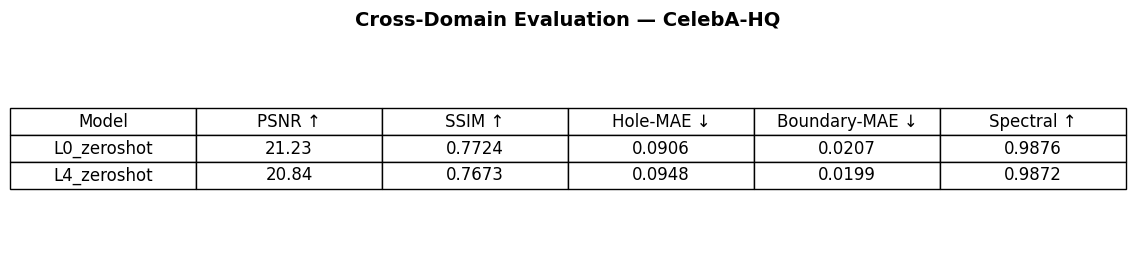

In [46]:
# ── 15.3 Cross-Domain Results Table ───────────────────────────
if not cross_domain_results:
    print("⚠️  No cross-domain results to display.")
else:
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis("off")

    headers = ["Model", "PSNR ↑", "SSIM ↑", "Hole-MAE ↓", "Boundary-MAE ↓", "Spectral ↑"]
    rows    = [
        [
            label,
            f"{gm['psnr']:.2f}",
            f"{gm['ssim']:.4f}",
            f"{gm['hole_mae']:.4f}",
            f"{gm.get('boundary_mae', float('nan')):.4f}",
            f"{gm.get('spectral_coherence', float('nan')):.4f}",
        ]
        for label, gm in cross_domain_results.items()
    ]

    table = ax.table(cellText=rows, colLabels=headers, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.6)

    plt.title("Cross-Domain Evaluation — CelebA-HQ", fontweight="bold", fontsize=14)
    plt.savefig(RESULTS_DIR / "cross_domain_results.png", dpi=150, bbox_inches="tight")
    plt.show()

## 16. Save Results & Paper-Ready Tables

In [47]:
# ── 16.1 Save All Results to JSON ─────────────────────────────

# Build phase1/2/3 summaries safely
def _phase_summary(results_dict):
    return {k: {"best_val_loss": v.get("best_val_loss", float("nan")),
                "elapsed_min": v.get("elapsed_min", 0.0)}
            for k, v in results_dict.items()}

all_results = {
    "phase1":        _phase_summary(phase1_results),
    "phase1_winner": p1_winner,
    "phase2":        _phase_summary(phase2_results),
    "phase2_winner": p2_winner,
    "phase3":        _phase_summary(phase3_results),
    "phase3_winner": p3_winner,
    "phase4_eval":   phase4_eval,
    "cross_domain":  cross_domain_results,
    "config": {
        "backbone":       BEST_BACKBONE,
        "skip_type":      p2_winner,
        "conv_type":      p3_winner,
        "use_attention_skip": USE_ATTENTION_SKIP,
        "use_gated_conv":    USE_GATED_CONV,
        "batch_size":     BATCH_SIZE,
        "img_size":       IMG_SIZE,
        "phase4_epochs_ablation": PHASE4_EPOCHS_ABLATION,
        "phase4_epochs_full":     PHASE4_EPOCHS_FULL,
        "lr_peak":        LR_PEAK,
        "loss_weights": {
            "hole":       HOLE_LOSS_WEIGHT,
            "valid":      VALID_LOSS_WEIGHT,
            "perceptual": PERCEPTUAL_LOSS_WEIGHT,
            "boundary":   BOUNDARY_LOSS_WEIGHT,
            "spectral":   SPECTRAL_LOSS_WEIGHT,
            "tv":         TV_LOSS_WEIGHT,
        },
    },
}

results_json = RESULTS_DIR / "all_results.json"
with open(results_json, "w") as f:
    json.dump(all_results, f, indent=2, default=str)

print(f"All results saved to {results_json}")

All results saved to results/all_results.json


### 16.2 Paper-Ready Ablation Table (CSV)
Exports a clean CSV of the Phase 4 ablation metrics, formatted for direct inclusion in a LaTeX `\\input{}` or spreadsheet.

In [48]:
# ── 16.2 Paper-Ready Ablation Table (CSV) ─────────────────────
csv_path = RESULTS_DIR / "ablation_table.csv"
fieldnames = [
    "Experiment", "PSNR", "SSIM", "Full-MAE", "Hole-MAE",
    "Valid-MAE", "Boundary-MAE", "Spectral-Coherence",
]

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for exp_name in phase4_eval:   # only completed experiments
        g = phase4_eval[exp_name]["global"]
        writer.writerow({
            "Experiment":         exp_name,
            "PSNR":               f"{g['psnr']:.4f}",
            "SSIM":               f"{g['ssim']:.4f}",
            "Full-MAE":           f"{g['full_mae']:.4f}",
            "Hole-MAE":           f"{g['hole_mae']:.4f}",
            "Valid-MAE":          f"{g['valid_mae']:.4f}",
            "Boundary-MAE":       f"{g['boundary_mae']:.4f}",
            "Spectral-Coherence": f"{g['spectral_coherence']:.4f}",
        })

print(f"Ablation table saved to {csv_path}")

Ablation table saved to results/ablation_table.csv


### 16.3 Final Summary
Prints the architecture decisions from Phases 1–3 and the final L4 test metrics for a quick end-to-end verification that the full pipeline ran correctly.

In [49]:
# ── 16.3 Final Summary ────────────────────────────────────────
print("\n" + "="*60)
print("EXPERIMENT COMPLETE")
print("="*60)

print("\nArchitecture decisions:")
print(f"  Backbone:   {BEST_BACKBONE}")
print(f"  Skip conn:  {p2_winner} (use_attention_skip={USE_ATTENTION_SKIP})")
print(f"  Conv type:  {p3_winner} (use_gated_conv={USE_GATED_CONV})")

if "L4_full_method" in phase4_eval:
    print("\nFinal model (L4) test metrics:")
    for k, v in phase4_eval["L4_full_method"]["global"].items():
        print(f"  {k}: {v:.4f}")
else:
    print("\n⚠️  L4_full_method evaluation not found — check training logs.")

print(f"\nFigures  → {RESULTS_DIR}/")
print(f"Checkpts → {CKPT_SAVE_DIR}/")
print(f"JSON     → {RESULTS_DIR / 'all_results.json'}")
print(f"CSV      → {RESULTS_DIR / 'ablation_table.csv'}")

print("\nSaved figures:")
for fig_path in sorted(RESULTS_DIR.glob("*.png")):
    print(f"  {fig_path.name}")


EXPERIMENT COMPLETE

Architecture decisions:
  Backbone:   resnet34
  Skip conn:  attention_mask (use_attention_skip=True)
  Conv type:  gated_conv (use_gated_conv=True)

Final model (L4) test metrics:
  psnr: 20.0158
  ssim: 0.7132
  full_mae: 0.0498
  hole_mae: 0.1078
  valid_mae: 0.0000
  boundary_mae: 0.0311
  spectral_coherence: 0.9836
  coverage: 0.4537

Figures  → results/
Checkpts → checkpoints/
JSON     → results/all_results.json
CSV      → results/ablation_table.csv

Saved figures:
  cross_domain_results.png
  eda_boundary_band.png
  eda_mask_coverage.png
  eda_mask_examples.png
  eda_pixel_intensity.png
  eda_resolution_dist.png
  eda_sample_grid.png
  eda_stage1_vs_stage2.png
  error_distribution.png
  failure_cases.png
  phase1_results.png
  phase2_results.png
  phase3_results.png
  phase4_ablation_table.png
  phase4_stratified.png
  phase4_training_curves.png
  qualitative_comparison.png
